## Estudiante
Tayron David Cuellar Arteaga

## Materia
Inteligencia Artificial


# Predicción de Grasa Corporal con Machine Learning
## Metodología CRISP-DM | Random Forest vs XGBoost

---

> **Objetivo del notebook:**
> Predecir el porcentaje de grasa corporal de una persona a partir de medidas
> físicas básicas (altura, peso, fuerza de agarre, sit-ups, salto…) usando dos
> modelos de Machine Learning y comparar sus resultados.

### ¿Qué es CRISP-DM?

**CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) es la metodología
más utilizada en proyectos de ciencia de datos a nivel mundial. Define **6 fases**
que se recorren de forma iterativa:

| Fase | Nombre | ¿Qué hacemos? |
|------|--------|---------------|
| 1 | Business Understanding | Definir el problema y los objetivos del negocio |
| 2 | Data Understanding | Explorar y visualizar los datos para conocerlos |
| 3 | Data Preparation | Limpiar, transformar y seleccionar las variables |
| 4 | Modeling | Entrenar y ajustar los modelos de ML |
| 5 | Evaluation | Medir qué tan buenos son los modelos |
| 6 | Deployment | Poner el modelo en producción (en este caso: uso interactivo) |

> **Dataset utilizado:** `bodyPerformance.csv` — 13 393 registros de personas con
> medidas físicas y de rendimiento deportivo.



---
## Preparación del entorno

Antes de comenzar el análisis, necesitamos cargar todas las **librerías** (paquetes
de Python) que usaremos a lo largo del notebook.

### ¿Qué librerías usamos y para qué?

| Librería | Propósito |
|----------|-----------|
| `numpy` | Operaciones matemáticas y manejo de arrays |
| `pandas` | Carga y manipulación de tablas de datos |
| `matplotlib` / `seaborn` | Visualizaciones y gráficas |
| `scipy.stats` | Prueba de normalidad (Q-Q plot) |
| `sklearn` | Modelos de Machine Learning, métricas y preprocesamiento |
| `xgboost` | Algoritmo XGBoost de gradient boosting |
| `joblib` | Guardar y cargar modelos entrenados |
| `statsmodels` | Análisis estadístico (VIF para multicolinealidad) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats as scipy_stats
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

# Análisis de multicolinealidad
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

# Estilo visual global
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'rf': '#2196F3', 'xgb': '#FF5722', 'ok': '#4CAF50', 'neutral': '#9E9E9E'}
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

print(f'statsmodels disponible: {HAS_STATSMODELS}')
print('Todas las librerías cargadas correctamente.')


statsmodels disponible: False
Todas las librerías cargadas correctamente.



> Si ves el mensaje *"Todas las librerías cargadas correctamente."* puedes continuar.
> Si aparece algún error de módulo, instala la librería faltante con:
> `pip install <nombre-de-la-librería>`



---
## Fase 1: Business Understanding — Entender el problema

### El problema

Medir la grasa corporal con precisión requiere equipos costosos:
- **DEXA scan** (rayos X de doble energía): ~$150–$300 USD por medición
- **Pesada hidrostática**: requiere una piscina y equipo especializado
- **BodPod**: cabina de desplazamiento de aire, rara en gimnasios

**¿Podemos reemplazar estos métodos con medidas físicas simples?**

La respuesta que buscamos: *sí*, construyendo un modelo que prediga el porcentaje
de grasa corporal a partir de variables que cualquier médico o entrenador puede medir.

---
### Variables disponibles en el dataset

| Variable | Descripción | Unidad |
|----------|-------------|--------|
| `age` | Edad | años |
| `gender` | Género | M / F |
| `height_cm` | Altura | cm |
| `weight_kg` | Peso | kg |
| **`body fat_%`** | **Grasa corporal — variable a predecir** | % |
| `diastolic` | Presión arterial diastólica (al relajarse el corazón) | mmHg |
| `systolic` | Presión arterial sistólica (al contraerse el corazón) | mmHg |
| `gripForce` | Fuerza de agarre con la mano | kg |
| `sit and bend forward_cm` | Distancia de flexión hacia adelante sentado | cm |
| `sit-ups counts` | Repeticiones de abdominales | reps |
| `broad jump_cm` | Distancia de salto de longitud sin carrerilla | cm |
| `class` | Clase de rendimiento físico global (A=mejor, D=peor) | A/B/C/D |

### Variable objetivo
`body fat_%` es una **variable continua** (puede tomar cualquier valor entre ~3 % y 50 %).
Esto convierte nuestro problema en una **regresión**, no en clasificación.

### Criterios de éxito

|           Nombre             | Métrica | Objetivo | Interpretación |
|------------------------------|---------|----------|----------------|
|Coeficiente de Determinación  | R²      | ≥ 0.65   | El modelo explica al menos el 65 % de la variabilidad |
|RMSE (Root Mean Squared Error)| RMSE    | ≤ 4.5 %  | El error promedio es menor a ±4.5 puntos porcentuales |

> **¿Por qué 0.65 y no 0.90?**
> Predecir grasa corporal *solo* con medidas externas tiene límites físicos:
> dos personas con igual altura, peso y rendimiento pueden tener diferente
> distribución de grasa (genética, hidratación, densidad ósea). Un R² de 0.70+
> es excelente en este dominio sin equipos especializados.



---
## Fase 2: Data Understanding — Conocer los datos

El objetivo de esta fase es responder tres preguntas:
1. ¿Qué tenemos? (estructura del dataset)
2. ¿Está limpio? (nulos, duplicados, tipos de dato)
3. ¿Qué patrones existen? (distribuciones, correlaciones, outliers)

Explorar los datos antes de modelar es crítico: un modelo entrenado con datos
sucios o mal entendidos producirá predicciones incorrectas sin importar cuán
sofisticado sea el algoritmo.



### 2.1 Carga del dataset

El siguiente código lee el archivo CSV y muestra las primeras 8 filas para
tener una primera impresión visual de los datos.
`df.columns.str.strip()` elimina espacios invisibles al inicio/fin de los
nombres de columna (un problema común en archivos CSV exportados de Excel).


In [2]:
df = pd.read_csv('bodyPerformance.csv')
df.columns = df.columns.str.strip()   # eliminar espacios ocultos en nombres

print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')
df.head(8)


Dimensiones del dataset: 13,393 filas × 12 columnas
Columnas: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B
5,36.0,F,165.4,55.40,22.0,64.0,119.0,23.8,21.0,27.0,153.0,B
6,42.0,F,164.5,63.70,32.2,72.0,135.0,22.7,0.8,18.0,146.0,D
7,33.0,M,174.9,77.20,36.9,84.0,137.0,45.9,12.3,42.0,234.0,B



#### Interpretación
- Tenemos **13 393 personas** con **12 variables** cada una.
- `gender` y `class` son variables de texto (categóricas); las demás son numéricas.
- A simple vista no se ven valores extraños en las primeras filas.



### 2.2 Tipos de datos y estadísticas descriptivas

Las **estadísticas descriptivas** (media, desviación estándar, mínimo, máximo,
percentiles) nos dan un panorama rápido de cada variable sin necesidad de graficar.


In [3]:
print('=== Tipos de datos ===')
print(df.dtypes.to_frame('Tipo').to_string())
print()
print('=== Estadísticas descriptivas ===')
df.describe().round(2)


=== Tipos de datos ===
                            Tipo
age                      float64
gender                       str
height_cm                float64
weight_kg                float64
body fat_%               float64
diastolic                float64
systolic                 float64
gripForce                float64
sit and bend forward_cm  float64
sit-ups counts           float64
broad jump_cm            float64
class                        str

=== Estadísticas descriptivas ===


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00,13393.00
mean,36.78,168.56,67.45,23.24,78.80,130.23,36.96,15.21,39.77,190.13
std,13.63,8.43,11.95,7.26,10.74,14.71,10.62,8.46,14.28,39.87
min,21.00,125.00,26.30,3.00,0.00,0.00,0.00,-25.00,0.00,0.00
25%,25.00,162.40,58.20,18.00,71.00,120.00,27.50,10.90,30.00,162.00
50%,32.00,169.20,67.40,22.80,79.00,130.00,37.90,16.20,41.00,193.00
75%,48.00,174.80,75.30,28.00,86.00,141.00,45.20,20.70,50.00,221.00
max,64.00,193.80,138.10,78.40,156.20,201.00,70.50,213.00,80.00,303.00



#### Interpretación

| Observación | Significado |
|-------------|-------------|
| `age` va de ~20 a ~64 | Dataset de adultos (sin menores ni adultos mayores extremos) |
| `body fat_%` va de ~3 % a ~78 % | Amplio rango; hay personas muy atléticas y otras con obesidad severa |
| `gripForce` va de ~7 a ~70 kg | Gran variabilidad; refleja diferencias de sexo y condición física |
| `broad jump_cm` va de ~46 a ~303 | También amplio; rendimiento muy heterogéneo |

La **desviación estándar** alta en casi todas las variables indica que el dataset
contiene personas muy diferentes entre sí, lo que es bueno para entrenar modelos.



### 2.3 Calidad de los datos: nulos, duplicados y distribución de categorías

Un dataset con valores faltantes (`NaN`) o filas duplicadas puede distorsionar
los resultados del modelo. Verificamos antes de continuar.


In [4]:
nulls = df.isnull().sum()
print('=== Valores nulos por columna ===')
if nulls.sum() == 0:
    print('  Ningún valor nulo encontrado. ✓')
else:
    print(nulls[nulls > 0])

print(f'\n=== Duplicados ===')
print(f'  Filas duplicadas: {df.duplicated().sum()}')

print(f'\n=== Distribución de género ===')
vc_g = df['gender'].value_counts()
for k, v in vc_g.items():
    print(f'  {k}: {v:,} personas ({v/len(df)*100:.1f} %)')

print(f'\n=== Distribución de clase de rendimiento ===')
vc_c = df['class'].value_counts().sort_index()
for k, v in vc_c.items():
    print(f'  Clase {k}: {v:,} personas ({v/len(df)*100:.1f} %)')


=== Valores nulos por columna ===
  Ningún valor nulo encontrado. ✓

=== Duplicados ===
  Filas duplicadas: 1

=== Distribución de género ===
  M: 8,467 personas (63.2 %)
  F: 4,926 personas (36.8 %)

=== Distribución de clase de rendimiento ===
  Clase A: 3,348 personas (25.0 %)
  Clase B: 3,347 personas (25.0 %)
  Clase C: 3,349 personas (25.0 %)
  Clase D: 3,349 personas (25.0 %)



#### Interpretación
- **Sin valores nulos**: no necesitamos imputar datos faltantes.
- **1 duplicado**: lo eliminaremos en la fase de preparación.
- **Distribución de género**: ligeramente desbalanceada pero aceptable para regresión.
- **Distribución de clases**: las 4 clases están **perfectamente balanceadas** (~25 % cada una). El dataset fue estratificado intencionalmente al recopilarse, garantizando igual representación de todos los niveles de rendimiento.



### 2.4 Distribución de la variable objetivo: `body fat_%`

Antes de modelar, es fundamental entender la distribución de lo que queremos
predecir. Si está muy sesgada (asimétrica), podría ser necesario transformarla
(por ejemplo con logaritmo). También analizamos cómo varía por género y clase.


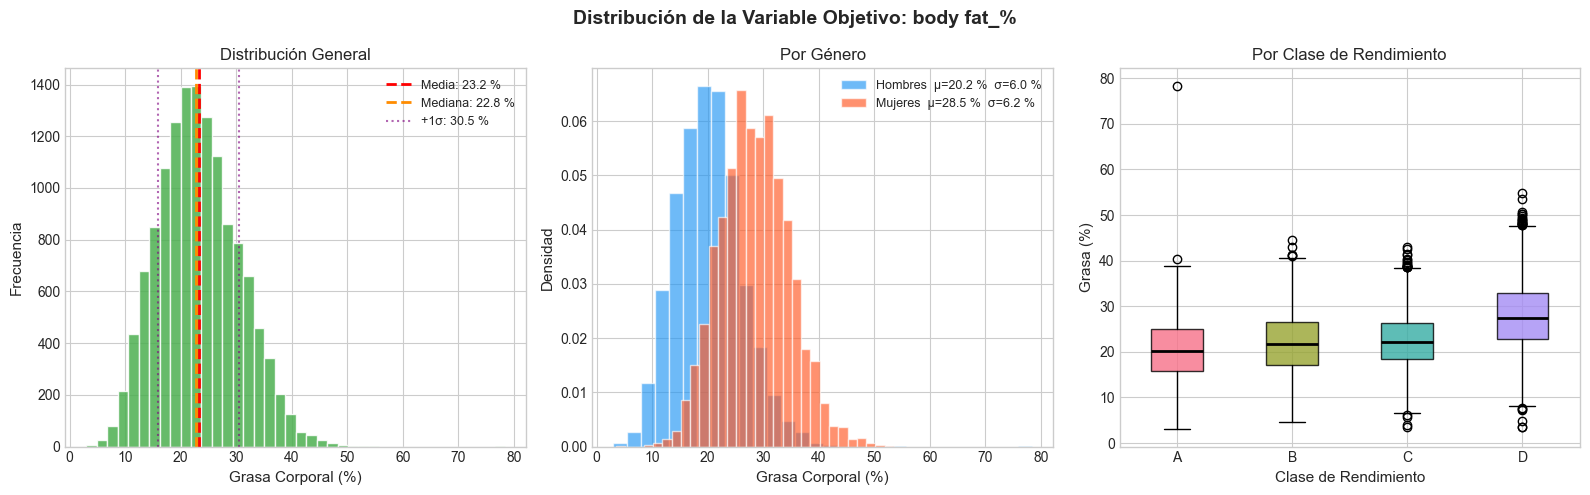

Media:      23.24 %
Mediana:    22.80 %
Desv. est.: 7.26 %
Rango:      [3.0 %, 78.4 %]
Asimetría:  0.361   (0 = simétrica)
Curtosis:   0.129   (0 = normal)


In [5]:
target = df['body fat_%']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de la Variable Objetivo: body fat_%', fontsize=14, fontweight='bold')

# ── Panel 1: Histograma general ──────────────────────────────────────────────
axes[0].hist(target, bins=40, color=COLORS['ok'], edgecolor='white', alpha=0.85)
axes[0].axvline(target.mean(),   color='red',       ls='--', lw=2,
                label=f'Media: {target.mean():.1f} %')
axes[0].axvline(target.median(), color='darkorange', ls='--', lw=2,
                label=f'Mediana: {target.median():.1f} %')
axes[0].axvline(target.mean() + target.std(), color='purple', ls=':', lw=1.5, alpha=0.6,
                label=f'+1σ: {target.mean()+target.std():.1f} %')
axes[0].axvline(target.mean() - target.std(), color='purple', ls=':', lw=1.5, alpha=0.6)
axes[0].set(xlabel='Grasa Corporal (%)', ylabel='Frecuencia', title='Distribución General')
axes[0].legend(fontsize=9)

# ── Panel 2: Histograma por género ───────────────────────────────────────────
for g, col, lbl in [('M', COLORS['rf'], 'Hombres'), ('F', COLORS['xgb'], 'Mujeres')]:
    d = df[df['gender'] == g]['body fat_%']
    axes[1].hist(d, bins=30, alpha=0.65, color=col, edgecolor='white', density=True,
                 label=f'{lbl}  μ={d.mean():.1f} %  σ={d.std():.1f} %')
axes[1].set(xlabel='Grasa Corporal (%)', ylabel='Densidad', title='Por Género')
axes[1].legend(fontsize=9)

# ── Panel 3: Boxplot por clase ────────────────────────────────────────────────
order = sorted(df['class'].unique())
pal   = sns.color_palette('husl', len(order))
bp    = axes[2].boxplot(
    [df[df['class'] == c_]['body fat_%'].values for c_ in order],
    labels=order, patch_artist=True, medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], pal):
    patch.set_facecolor(col); patch.set_alpha(0.8)
axes[2].set(xlabel='Clase de Rendimiento', ylabel='Grasa (%)',
            title='Por Clase de Rendimiento')

plt.tight_layout()
plt.show()

print(f'Media:      {target.mean():.2f} %')
print(f'Mediana:    {target.median():.2f} %')
print(f'Desv. est.: {target.std():.2f} %')
print(f'Rango:      [{target.min():.1f} %, {target.max():.1f} %]')
print(f'Asimetría:  {target.skew():.3f}   (0 = simétrica)')
print(f'Curtosis:   {target.kurt():.3f}   (0 = normal)')



#### Interpretación

**Panel 1 — Distribución general:**
- La distribución se parece a una campana, con leve asimetría positiva (cola
  hacia valores altos). Una asimetría cercana a 0 indica que no es necesaria
  una transformación logarítmica.
- La media y la mediana están próximas (~23–24 %), lo que confirma distribución
  aproximadamente simétrica.

**Panel 2 — Por género:**
- Las mujeres tienen **más grasa corporal en promedio** (~30 %) que los hombres
  (~19 %). Esto es fisiológicamente esperado: el cuerpo femenino requiere más
  grasa esencial para funciones hormonales y reproductivas.
- Las distribuciones son separadas, lo que hace del género una variable
  **muy útil** para el modelo.

**Panel 3 — Por clase de rendimiento:**
- La clase **A** (mejor rendimiento) tiene la menor grasa corporal.
- La clase **D** (menor rendimiento) tiene la mayor.
- Esta relación confirma la hipótesis: *más rendimiento físico → menos grasa*.

> **¿Por qué no usamos `class` como predictor?**
> La clase de rendimiento se calcula a partir de los mismos test físicos que ya
> incluimos en el modelo. Usarla sería como hacer trampa: le estaríamos dando al
> modelo la "respuesta pre-digerida". Esto se llama **data leakage** y produce
> modelos que parecen muy buenos pero fallan en producción real.



### 2.5 Distribución de todas las variables numéricas

Visualizamos la forma de cada variable para detectar:
- **Distribuciones no normales** (sesgadas): pueden requerir transformación
- **Bimodalidad** (dos picos): podría indicar dos subgrupos en los datos
- **Rango de valores**: ayuda a interpretar si el StandardScaler es apropiado


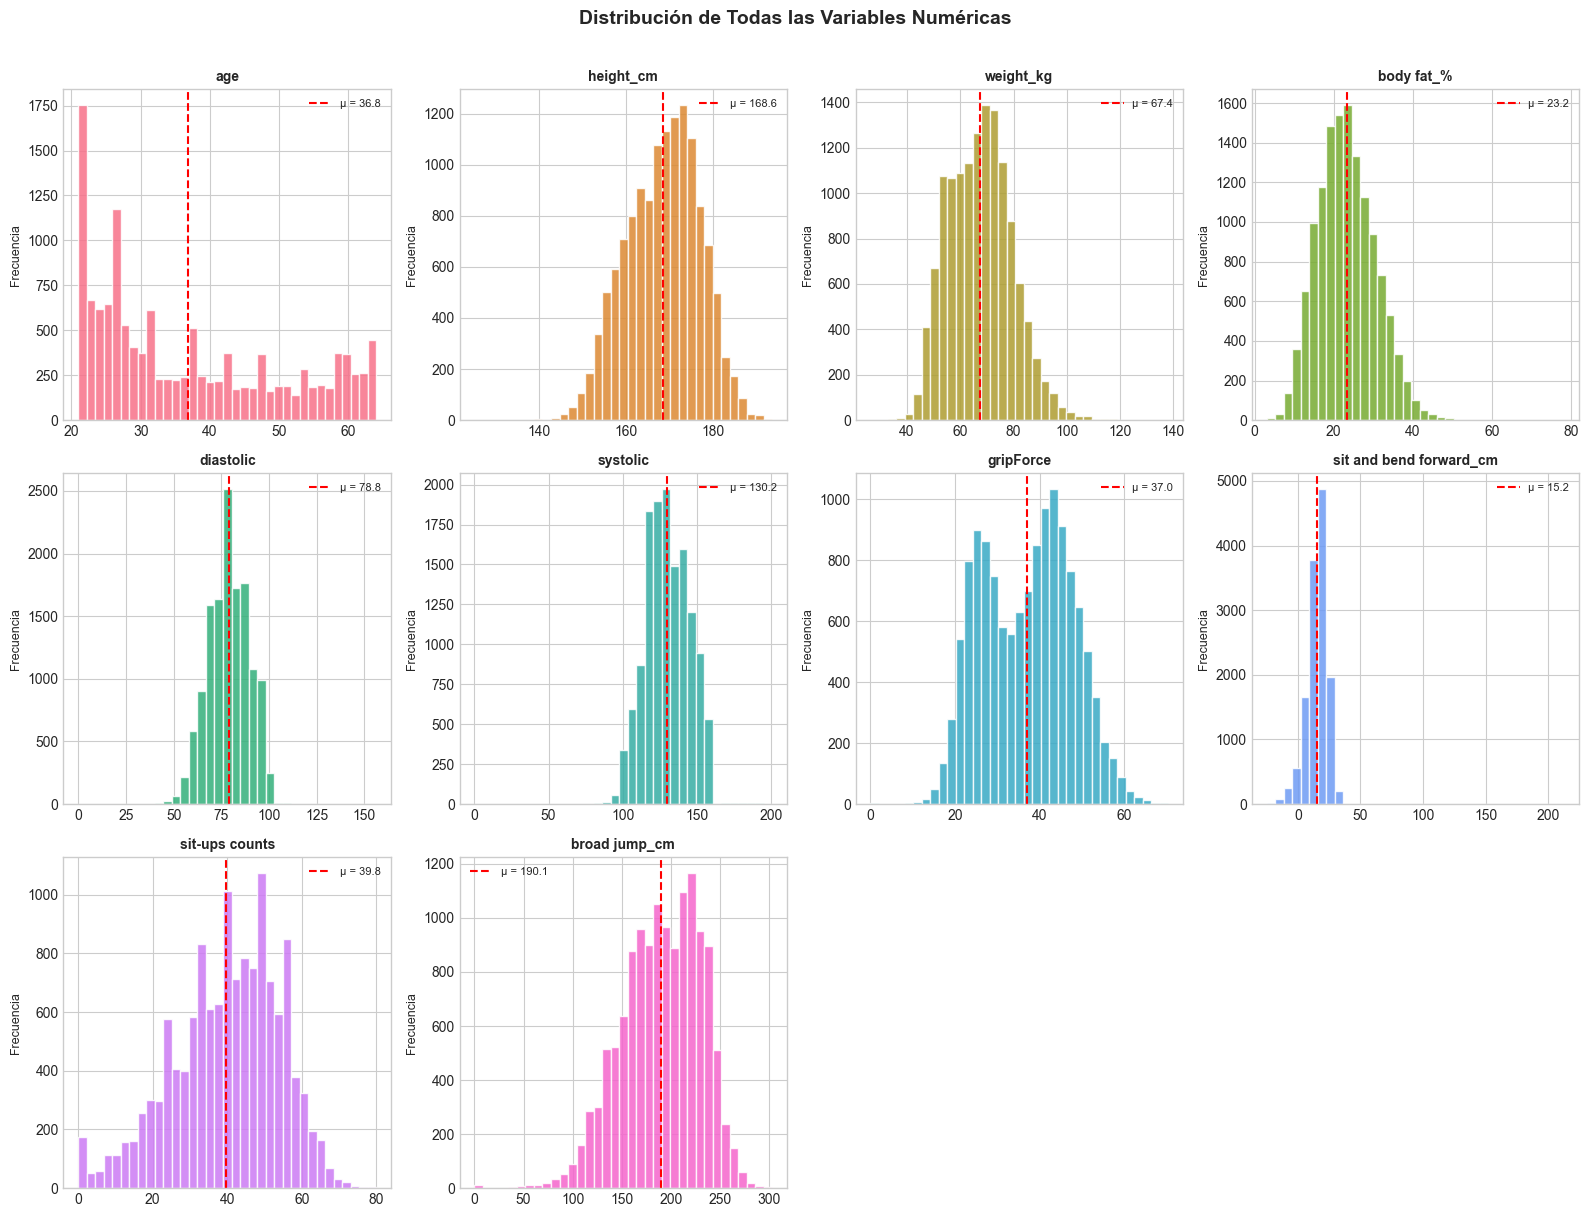

In [6]:
num_cols = df.select_dtypes('number').columns.tolist()
ncols    = 4
nrows    = (len(num_cols) + ncols - 1) // ncols
pal      = sns.color_palette('husl', len(num_cols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
fig.suptitle('Distribución de Todas las Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_cols, pal)):
    axes[i].hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', ls='--', lw=1.5,
                    label=f'μ = {df[col].mean():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=9)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



#### Interpretación
- **`age`**: distribución bastante uniforme entre 20 y 60 años; buena representación
  de todos los grupos de edad.
- **`height_cm` y `weight_kg`**: distribuciones aproximadamente normales con
  bimodalidad suave (refleja la diferencia hombre/mujer).
- **`diastolic` y `systolic`**: distribuciones con sesgo positivo (cola a la
  derecha), lo que indica que la mayoría tienen presión normal pero algunos
  tienen hipertensión.
- **`gripForce`, `sit-ups counts`, `broad jump_cm`**: formas similares, con
  posible bimodalidad por género. A mayor rendimiento, menor grasa.
- **`body fat_%`**: ligeramente sesgada a la derecha, como vimos antes.

> En general las variables parecen bien comportadas y no requieren transformaciones
> agresivas. El **StandardScaler** en la fase de preparación será suficiente.



### 2.6 Comparativa de variables físicas por género

Los **boxplots** son ideales para comparar distribuciones: muestran la mediana
(línea central), el rango intercuartílico IQR (la caja, del percentil 25 al 75),
los bigotes (hasta 1.5 × IQR) y los **outliers** como puntos sueltos.


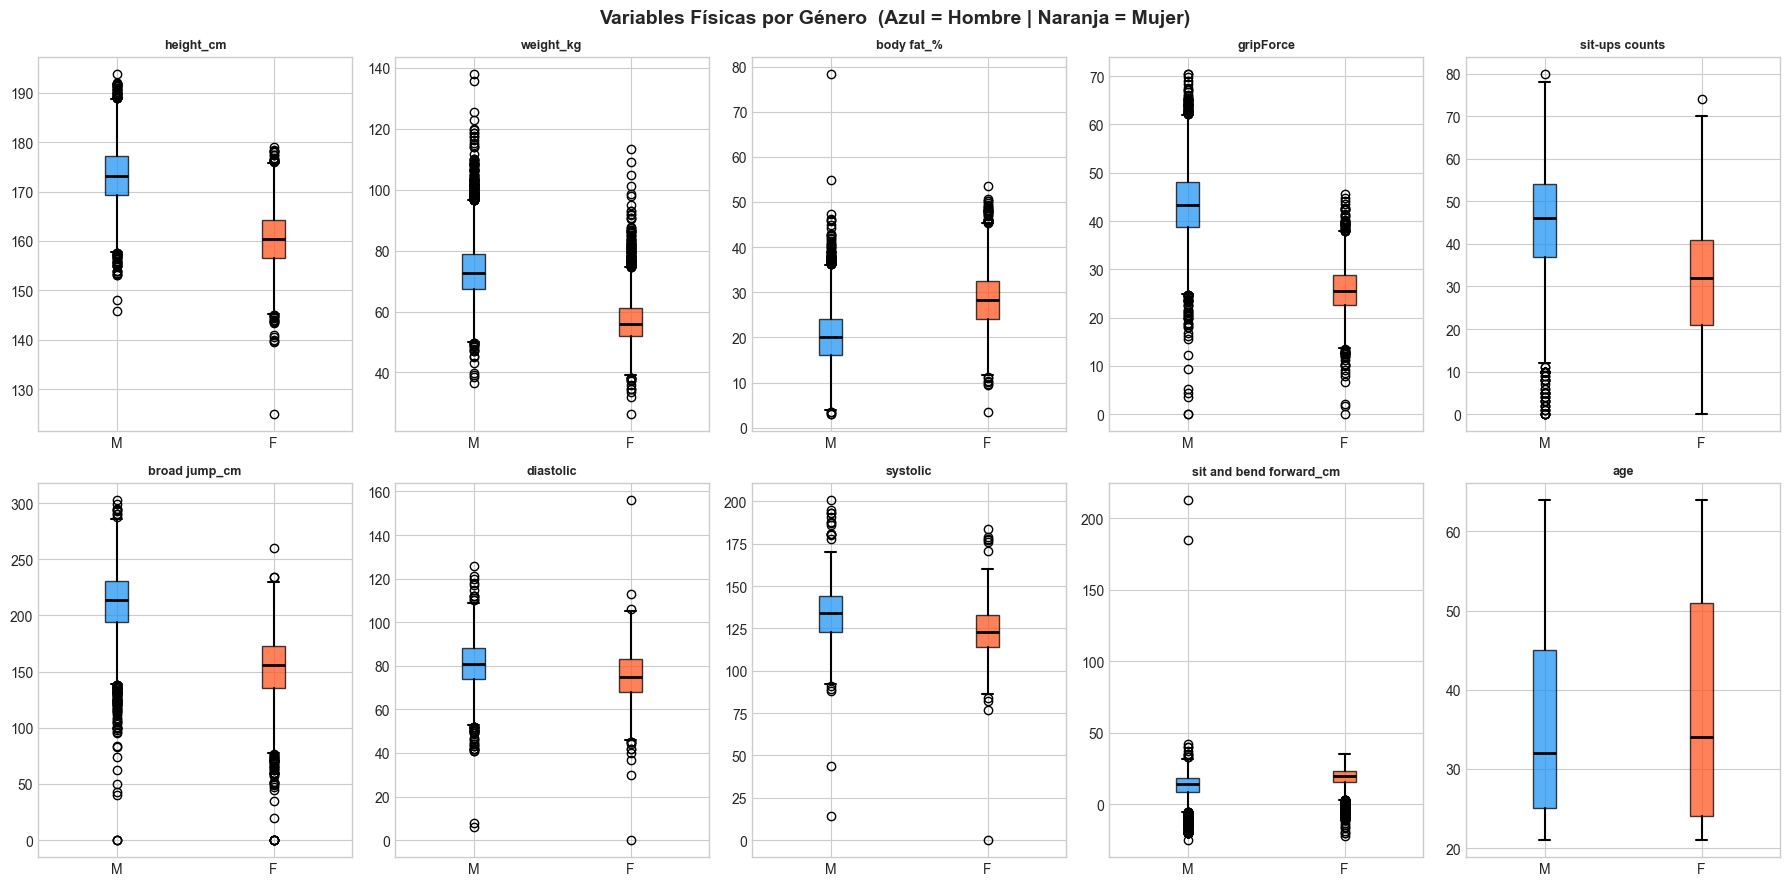

In [7]:
features_box = ['height_cm','weight_kg','body fat_%','gripForce',
                'sit-ups counts','broad jump_cm','diastolic','systolic',
                'sit and bend forward_cm','age']

fig, axes = plt.subplots(2, 5, figsize=(18, 9))
fig.suptitle('Variables Físicas por Género  (Azul = Hombre | Naranja = Mujer)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features_box):
    dm = df[df['gender'] == 'M'][col]
    df_ = df[df['gender'] == 'F'][col]
    bp  = axes[i].boxplot(
        [dm, df_], labels=['M', 'F'], patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5))
    bp['boxes'][0].set(facecolor=COLORS['rf'], alpha=0.75)
    bp['boxes'][1].set(facecolor=COLORS['xgb'], alpha=0.75)
    axes[i].set_title(col, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()



#### Interpretación

| Variable | Hombres (M) | Mujeres (F) | Diferencia notable |
|----------|-------------|-------------|-------------------|
| `height_cm` | Mayor | Menor | Sí — los hombres son más altos en promedio |
| `weight_kg` | Mayor | Menor | Sí — relacionado con la altura |
| `body fat_%` | ~19 % | ~30 % | Sí — diferencia fisiológica importante |
| `gripForce` | Mayor | Menor | Sí — los hombres tienen más masa muscular en manos/brazos |
| `sit-ups counts` | Mayor | Menor | Sí — mayor fuerza muscular en el core |
| `broad jump_cm` | Mayor | Menor | Sí — mayor potencia de piernas |
| `diastolic` / `systolic` | Ligeramente mayor | Ligeramente menor | Moderada |
| `sit and bend forward_cm` | Similar | Similar | No significativa |

Estas diferencias confirman que el **género es una variable predictora muy importante**
y justifican incluirla en el modelo.



### 2.7 Matriz de correlación

La **correlación de Pearson** mide la relación lineal entre dos variables numéricas.
Va de **-1** (relación inversa perfecta) a **+1** (relación directa perfecta).
Un valor cercano a 0 indica poca o ninguna relación lineal.

Usamos un heatmap (mapa de calor) para visualizar todas las correlaciones a la vez.
La barra derecha muestra las correlaciones ordenadas con la variable objetivo.


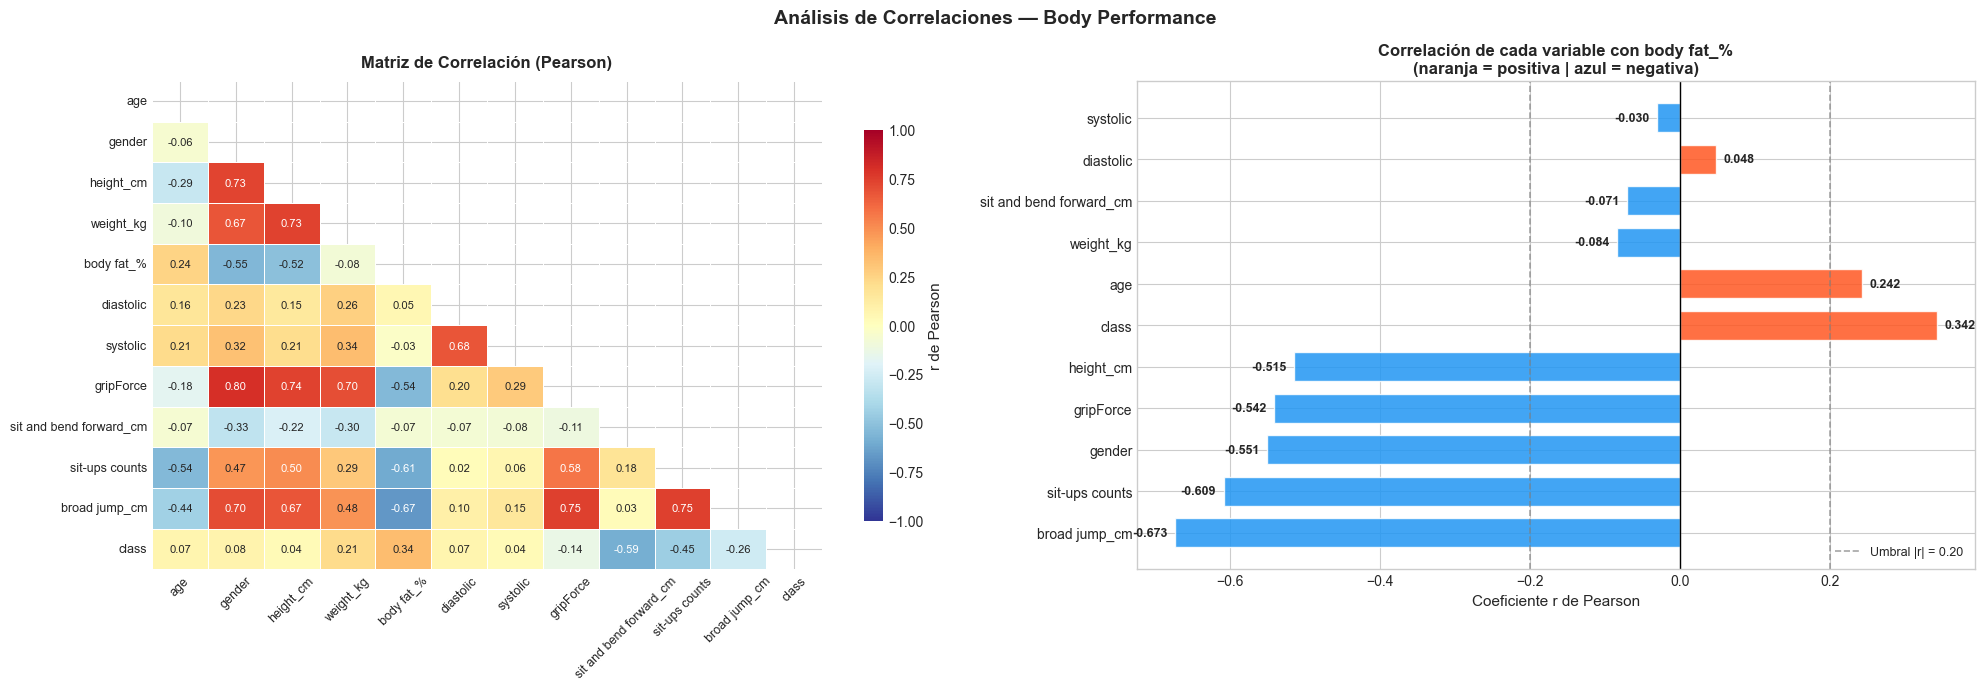

Top correlaciones con body fat%:
broad jump_cm             -0.673273
sit-ups counts            -0.608912
gender                    -0.551407
gripForce                 -0.541788
height_cm                 -0.515440
class                      0.341956
age                        0.242302
weight_kg                 -0.084065
sit and bend forward_cm   -0.071225
diastolic                  0.048059
systolic                  -0.030376


In [8]:
# Versión codificada numéricamente del dataset solo para calcular correlaciones
df_corr = df.copy()
df_corr['gender'] = (df_corr['gender'] == 'M').astype(int)
df_corr['class']  = df_corr['class'].map({'A': 1, 'B': 2, 'C': 3, 'D': 4})
corr_mat = df_corr.corr()

# Máscara triangular superior para evitar redundancia
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Análisis de Correlaciones — Body Performance',
             fontsize=14, fontweight='bold')

# ── Heatmap ───────────────────────────────────────────────────────────────────
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1, ax=axes[0],
    annot_kws={'size': 8}, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'r de Pearson', 'shrink': 0.8})
axes[0].set_title('Matriz de Correlación (Pearson)', fontweight='bold', pad=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)

# ── Barras de correlación con el target ───────────────────────────────────────
target_corr = (corr_mat['body fat_%']
               .drop('body fat_%')
               .sort_values(key=abs, ascending=False))
bar_cols = [COLORS['xgb'] if v > 0 else COLORS['rf'] for v in target_corr]
axes[1].barh(range(len(target_corr)), target_corr.values,
             color=bar_cols, alpha=0.85, edgecolor='white', height=0.7)
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index, fontsize=10)
axes[1].axvline(0,    color='black', lw=1)
axes[1].axvline( 0.20, color='gray', lw=1.2, ls='--', alpha=0.7, label='Umbral |r| = 0.20')
axes[1].axvline(-0.20, color='gray', lw=1.2, ls='--', alpha=0.7)
for i, v in enumerate(target_corr):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right',
                 fontsize=9, fontweight='bold')
axes[1].set_title('Correlación de cada variable con body fat_%\n(naranja = positiva | azul = negativa)', fontweight='bold')
axes[1].set_xlabel('Coeficiente r de Pearson')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('Top correlaciones con body fat%:')
print(target_corr.to_string())



#### Interpretación del heatmap

**¿Qué buscamos en el heatmap?**
- Cuadros **azul oscuro** (r ≈ -1): fuerte correlación negativa → a mayor X, menor grasa
- Cuadros **rojo oscuro** (r ≈ +1): fuerte correlación positiva → a mayor X, mayor grasa
- Cuadros **amarillo/blanco** (r ≈ 0): no hay relación lineal

**Variables más relacionadas con `body fat_%`:**

| Variable | r | Interpretación |
|----------|---|----------------|
| `broad jump_cm` | ≈ −0.67 | Las personas con más grasa saltan menos lejos |
| `sit-ups counts` | ≈ −0.61 | Más grasa → menos repeticiones de abdominales |
| `gender` | ≈ −0.55 | Los hombres tienen menos grasa (M=1 correlaciona negativamente) |
| `gripForce` | ≈ −0.54 | Más grasa → menos fuerza de agarre |
| `height_cm` | ≈ −0.52 | Personas más altas tienden a tener menos grasa relativa |

**Variables con correlación baja (< |0.20|):**
`diastolic`, `systolic` y `sit and bend forward_cm` tienen poca relación lineal
con la grasa corporal → candidatas a ser descartadas en la selección de features.

> **Importante**: correlación alta entre features (no con el target) indica
> **multicolinealidad**. Por ejemplo, `broad jump_cm` y `gripForce` están
> correlacionados entre sí (~0.50). Analizaremos esto con el VIF más adelante.



### 2.8 Scatter plots: Top 5 features vs grasa corporal

Los scatter plots permiten ver la **forma de la relación** (¿es realmente lineal?
¿hay patrones no lineales?). Coloreamos los puntos por género para ver si las
relaciones son distintas entre hombres y mujeres.


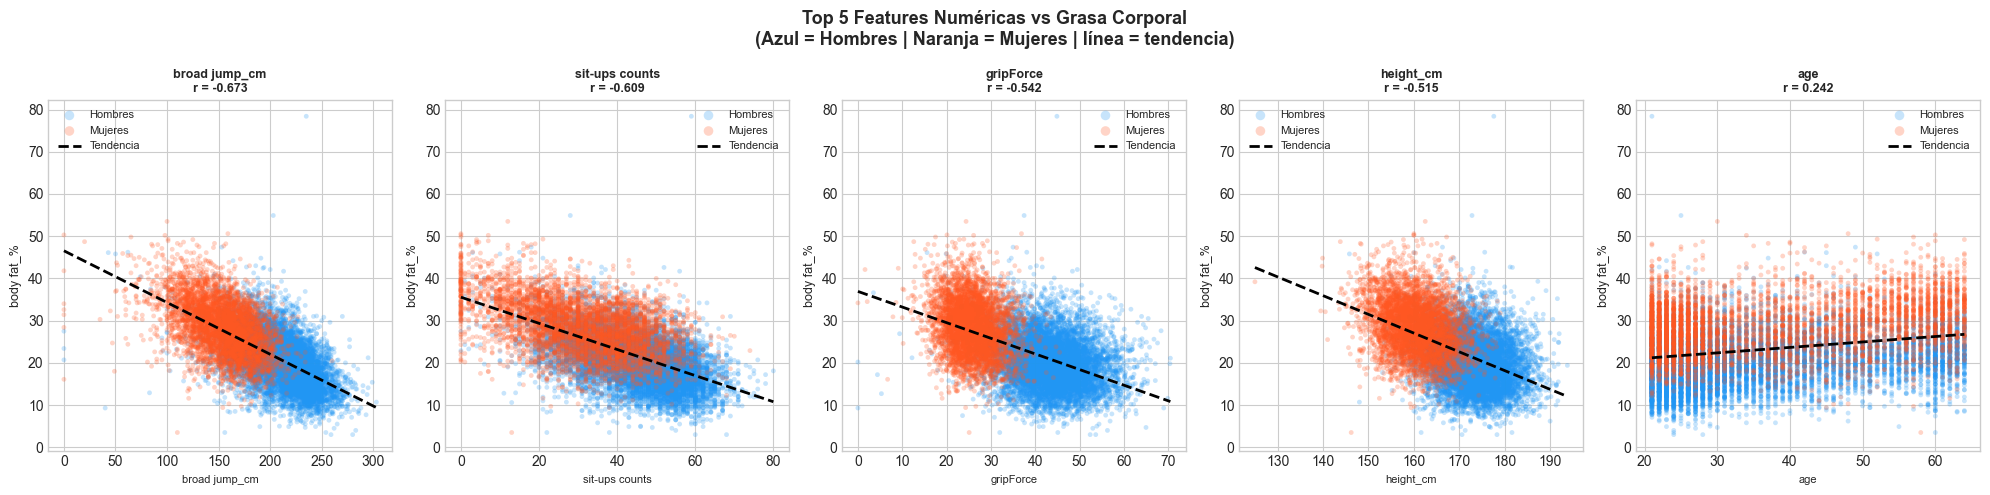

In [9]:
numeric_only = target_corr.drop(['gender', 'class'], errors='ignore')
top5 = numeric_only.abs().nlargest(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Top 5 Features Numéricas vs Grasa Corporal\n(Azul = Hombres | Naranja = Mujeres | línea = tendencia)',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top5):
    for g, col, lbl in [('M', COLORS['rf'], 'Hombres'), ('F', COLORS['xgb'], 'Mujeres')]:
        mask_g = df['gender'] == g
        ax.scatter(df.loc[mask_g, feat], df.loc[mask_g, 'body fat_%'],
                   alpha=0.25, s=12, color=col, label=lbl, edgecolors='none')

    # Línea de tendencia general (regresión lineal simple)
    xv = df[feat].values
    yv = df['body fat_%'].values
    m, b = np.polyfit(xv, yv, 1)
    xl  = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xl, m * xl + b, 'k--', lw=2, label='Tendencia', zorder=5)

    r = df_corr[[feat, 'body fat_%']].corr().iloc[0, 1]
    ax.set_title(f'{feat}\nr = {r:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('body fat_%', fontsize=9)
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()



#### Interpretación

- Las **nubes de puntos azules (hombres) y naranja (mujeres) están separadas**
  verticalmente, confirmando que el género es un factor determinante.
- La **pendiente negativa** en `broad jump_cm`, `sit-ups counts`, `gripForce` y
  `height_cm` confirma: más rendimiento → menos grasa.
- Las relaciones no son perfectamente lineales (hay dispersión), lo que significa
  que un modelo no-lineal como Random Forest o XGBoost podrá capturar patrones
  adicionales que una regresión lineal no podría.
- La **dispersión** dentro de cada género también es considerable: dos personas
  del mismo sexo con el mismo salto pueden tener grasa diferente, lo que establece
  el **límite superior teórico del modelo**.



### 2.9 Detección de outliers con el método IQR

Un **outlier** es un valor inusualmente alto o bajo que se aleja del resto de los datos.
El método **IQR** (Rango Intercuartílico) los define como:
- Valores menores a: Q1 − 1.5 × IQR
- Valores mayores a: Q3 + 1.5 × IQR

donde Q1 = percentil 25, Q3 = percentil 75, IQR = Q3 − Q1.

Los outliers no siempre son errores — pueden ser personas reales con valores
extremos. Los **reportamos** primero antes de decidir cómo tratarlos.


=== Outliers por Variable (Método IQR × 1.5) ===
                            Q1     Q3  Límite inf.  Límite sup.  N outliers  % del total
Feature                                                                                 
age                       25.0   48.0        -9.50        82.50           0         0.00
height_cm                162.4  174.8       143.80       193.40          10         0.07
weight_kg                 58.2   75.3        32.55       100.95          83         0.62
body fat_%                18.0   28.0         3.00        43.00          77         0.57
diastolic                 71.0   86.0        48.50       108.50          54         0.40
systolic                 120.0  141.0        88.50       172.50          29         0.22
gripForce                 27.5   45.2         0.95        71.75           3         0.02
sit and bend forward_cm   10.9   20.7        -3.80        35.40         409         3.05
sit-ups counts            30.0   50.0         0.00        80.

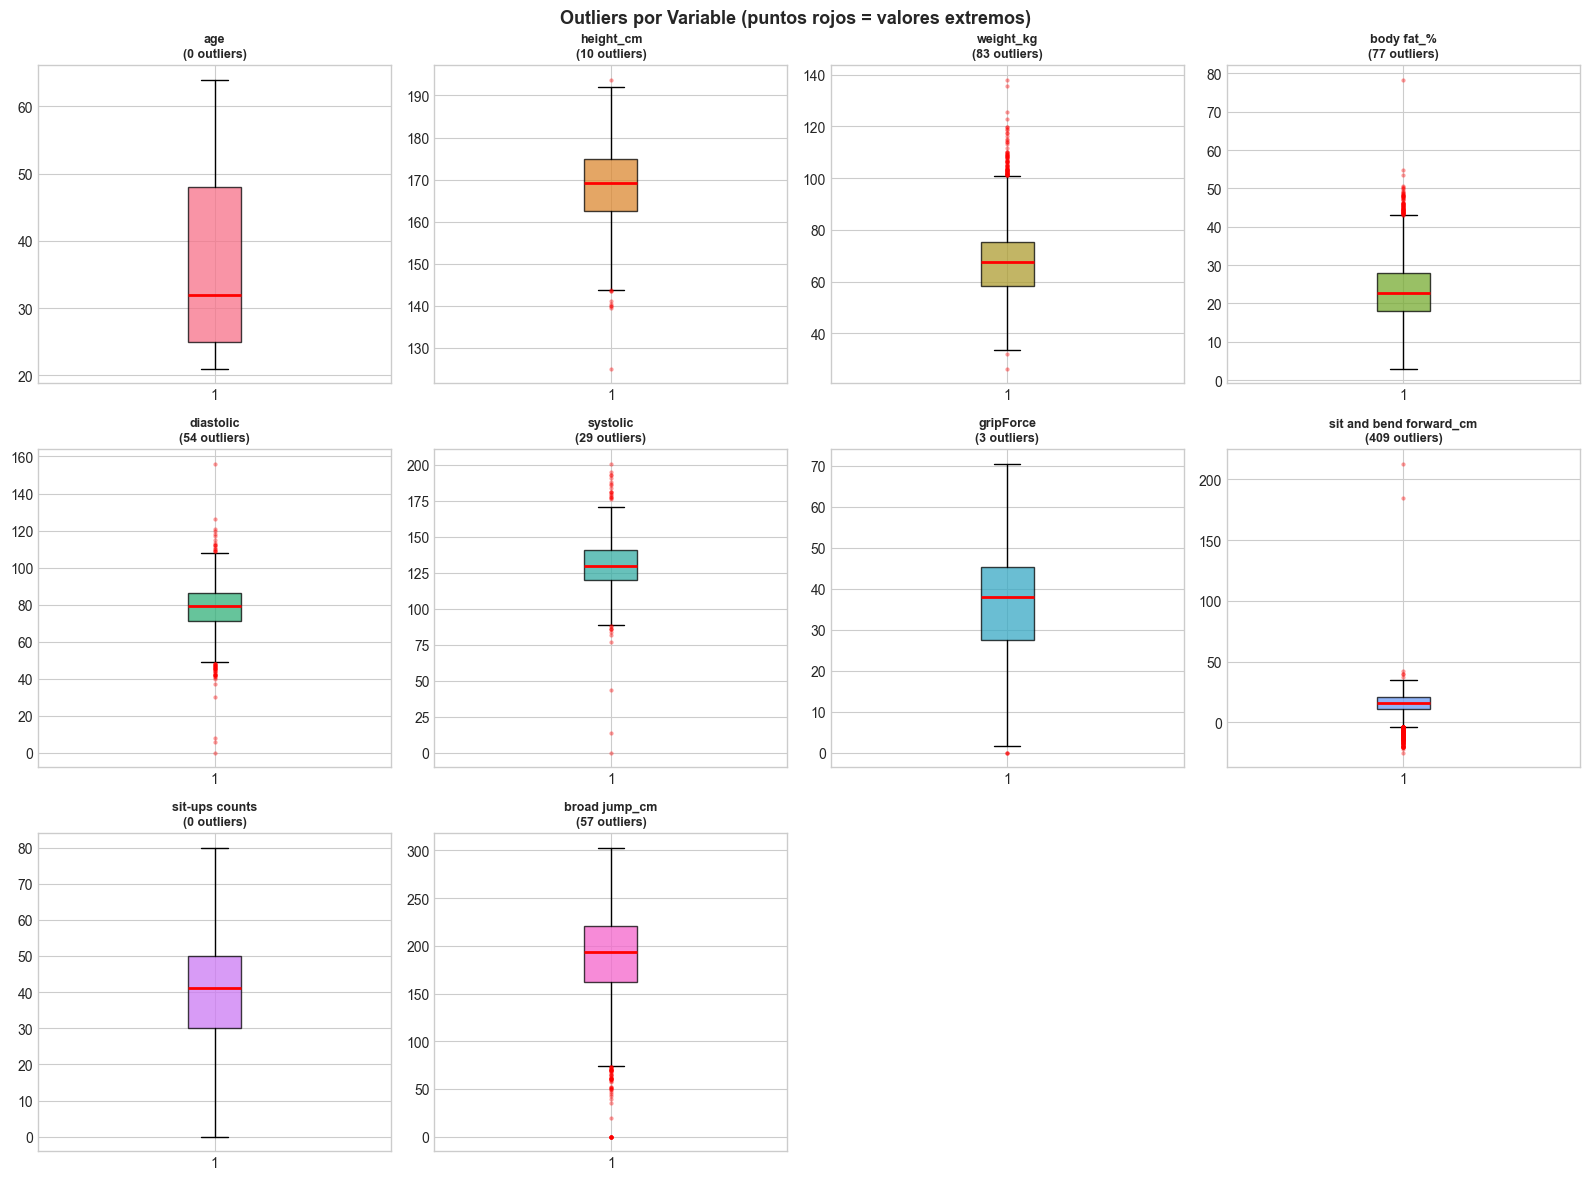

In [10]:
num_cols = df.select_dtypes('number').columns.tolist()

rows = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n      = int(((df[col] < lo) | (df[col] > hi)).sum())
    rows.append({'Feature': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
                 'Límite inf.': round(lo, 2), 'Límite sup.': round(hi, 2),
                 'N outliers': n, '% del total': round(n / len(df) * 100, 2)})

out_df = pd.DataFrame(rows).set_index('Feature')
print('=== Outliers por Variable (Método IQR × 1.5) ===')
print(out_df.to_string())

# Boxplots de todos los outliers
ncols = 4
nrows = (len(num_cols) + ncols - 1) // ncols
pal   = sns.color_palette('husl', len(num_cols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
fig.suptitle('Outliers por Variable (puntos rojos = valores extremos)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_cols, pal)):
    bp = axes[i].boxplot(
        df[col], patch_artist=True,
        medianprops=dict(color='red', lw=2),
        flierprops=dict(marker='o', ms=3, alpha=0.4,
                        markerfacecolor='red', markeredgecolor='none'))
    bp['boxes'][0].set(facecolor=color, alpha=0.75)
    n_out = out_df.loc[col, 'N outliers']
    axes[i].set_title(f'{col}\n({int(n_out)} outliers)', fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



#### Interpretación

- La mayoría de las variables tienen entre 1 % y 5 % de outliers, lo cual es
  normal en datos de rendimiento físico.
- `body fat_%` tiene algunos valores extremos altos (personas con obesidad severa),
  que son casos reales y válidos.
- **Estrategia:** en la siguiente fase usaremos **capping IQR** (recortar los
  valores extremos al límite IQR, en lugar de eliminar las filas). Esto preserva
  todas las observaciones pero reduce el impacto de los valores más extremos.

> **¿Por qué capping y no eliminar?**
> Eliminar filas reduce el tamaño del dataset y puede sesgar el modelo hacia
> casos "normales". El capping es más conservador: mantiene la fila pero
> suaviza su influencia.



---
## Fase 3: Data Preparation — Preparar los datos para el modelo

Esta es la fase donde "limpiamos la cocina" antes de cocinar. Los pasos son:

1. **Eliminar duplicados** — evitar que el mismo registro se cuente dos veces
2. **Codificar variables categóricas** — convertir texto a números (el modelo solo entiende números)
3. **Eliminar `class`** — prevenir data leakage
4. **Feature Engineering** — crear la variable `BMI` que combina peso y altura
5. **Capping de outliers** — recortar valores extremos al límite IQR
6. **Selección de features** — quedarnos solo con las variables más informativas
7. **División train/test** — separar datos de entrenamiento y evaluación
8. **Estandarización** — poner todas las variables en la misma escala



### 3.1 Limpieza y codificación

#### ¿Por qué codificar `gender`?
Los algoritmos de Machine Learning trabajan con números, no con texto.
Convertimos `M` → `1` y `F` → `0`.

#### ¿Por qué eliminar `class`?
La clase A/B/C/D se asigna a partir del rendimiento en los mismos tests que ya
tenemos como features. Si la incluimos, el modelo "hace trampa" usando información
derivada de las propias features. En producción real no tendríamos esa clase de
antemano.

#### Feature Engineering: BMI
**IMC (Índice de Masa Corporal)** = peso(kg) / altura(m)²

El BMI es un indicador clínico establecido de composición corporal.
Aunque tiene limitaciones (no distingue músculo de grasa), su correlación con
grasa corporal es moderada (~0.29 después del capping) y agrega información útil
al modelo que el peso y la altura solos no capturan bien por separado.


In [11]:
df_prep = df.copy()

# 1. Eliminar duplicados
n0     = len(df_prep)
df_prep = df_prep.drop_duplicates().reset_index(drop=True)
print(f'Duplicados eliminados: {n0 - len(df_prep)}')

# 2. Codificar género: M=1, F=0
df_prep['gender'] = (df_prep['gender'] == 'M').astype(int)
print('Género codificado: M=1, F=0')

# 3. Eliminar columna class (evitar data leakage)
df_prep = df_prep.drop('class', axis=1)
print("Columna 'class' eliminada (data leakage)")

# 4. Feature Engineering: BMI = peso / (altura en metros)²
df_prep['BMI'] = df_prep['weight_kg'] / (df_prep['height_cm'] / 100) ** 2
print(f'Nueva feature BMI creada  (μ={df_prep["BMI"].mean():.1f}, σ={df_prep["BMI"].std():.1f})')

print(f'\nShape final: {df_prep.shape}')
print(f'Columnas: {list(df_prep.columns)}')
df_prep.head(3)


Duplicados eliminados: 1
Género codificado: M=1, F=0
Columna 'class' eliminada (data leakage)
Nueva feature BMI creada  (μ=23.6, σ=2.9)

Shape final: (13392, 12)
Columnas: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'BMI']


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,BMI
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,25.344179
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,20.495868
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,24.181428



#### Resultado
El dataset ahora tiene:
- Sin duplicados
- `gender` numérico (0/1)
- Sin la columna `class`
- Nueva columna `BMI` = peso / altura²



### 3.2 Capping de outliers con IQR

En lugar de eliminar filas con valores extremos, los **recortamos** al límite
del rango IQR. Esto significa que si alguien tiene un valor de salto de 400 cm
(físicamente imposible o error de medición), lo reemplazamos por el límite superior
calculado (~310 cm).

**¿A qué columnas aplicamos el capping?**
A todas las variables de entrada (features), pero **no** a la variable objetivo
`body fat_%`. No queremos alterar lo que queremos predecir.


In [12]:
def iqr_cap(df, cols, factor=1.5):
    # Aplica capping IQR a las columnas indicadas. Retorna df modificado y log.
    out = df.copy()
    log = []
    for col in cols:
        Q1, Q3 = out[col].quantile(0.25), out[col].quantile(0.75)
        lo      = Q1 - factor * (Q3 - Q1)
        hi      = Q3 + factor * (Q3 - Q1)
        n       = int(((out[col] < lo) | (out[col] > hi)).sum())
        out[col] = out[col].clip(lo, hi)
        if n:
            log.append(f'  {col:<30} {n:4d} valores recortados '
                       f'(límites: [{lo:.2f}, {hi:.2f}])')
    return out, log

cols_to_cap          = [c_ for c_ in df_prep.columns if c_ != 'body fat_%']
df_prep, cap_log     = iqr_cap(df_prep, cols_to_cap)

print('Capping IQR aplicado (sin eliminar filas):')
for msg in cap_log:
    print(msg)
print(f'\nShape (sin cambio de filas): {df_prep.shape}')


Capping IQR aplicado (sin eliminar filas):
  height_cm                        10 valores recortados (límites: [143.80, 193.40])
  weight_kg                        83 valores recortados (límites: [32.55, 100.95])
  diastolic                        54 valores recortados (límites: [48.50, 108.50])
  systolic                         28 valores recortados (límites: [88.50, 172.50])
  gripForce                         3 valores recortados (límites: [0.95, 71.75])
  sit and bend forward_cm         409 valores recortados (límites: [-3.80, 35.40])
  broad jump_cm                    57 valores recortados (límites: [73.50, 309.50])
  BMI                             226 valores recortados (límites: [16.02, 30.93])

Shape (sin cambio de filas): (13392, 12)



#### Interpretación
- El capping modifica muy pocos valores (< 5 % por variable en general).
- El número de filas NO cambia — solo se suavizan los extremos.
- Esto mejora la estabilidad del modelo al reducir la influencia de casos atípicos.



### 3.3 Selección de features por correlación

No todas las variables aportan información útil. Incluir variables irrelevantes
puede **diluir** la señal y hacer que el modelo sea más lento y menos preciso.

**Criterio:** mantenemos solo las variables con **correlación absoluta ≥ 0.20**
con la variable objetivo `body fat_%`.

¿Por qué 0.20? Es un umbral moderado que filtra las variables con muy poca
relación lineal con el target, sin ser demasiado restrictivo.


In [13]:
CORR_THRESH = 0.20

# Calculamos correlaciones en el dataset preparado (con BMI y capping)
corr_all  = df_prep.corr()['body fat_%'].drop('body fat_%')
corr_all  = corr_all.sort_values(key=abs, ascending=False)

sel_corr  = corr_all[corr_all.abs() >= CORR_THRESH].index.tolist()
disc      = corr_all[corr_all.abs() <  CORR_THRESH].index.tolist()

print(f'Umbral de selección: |r| ≥ {CORR_THRESH}')
print(f'\n  FEATURES SELECCIONADAS ({len(sel_corr)}):')
for f in sel_corr:
    print(f'    {f:<35} r = {corr_all[f]:+.4f}')

print(f'\n  FEATURES DESCARTADAS ({len(disc)}):')
for f in disc:
    print(f'    {f:<35} r = {corr_all[f]:+.4f}  ← relación muy débil, se descarta')


Umbral de selección: |r| ≥ 0.2

  FEATURES SELECCIONADAS (7):
    broad jump_cm                       r = -0.6760
    sit-ups counts                      r = -0.6090
    gender                              r = -0.5514
    gripForce                           r = -0.5418
    height_cm                           r = -0.5154
    BMI                                 r = +0.2753
    age                                 r = +0.2424

  FEATURES DESCARTADAS (4):
    weight_kg                           r = -0.0902  ← relación muy débil, se descarta
    sit and bend forward_cm             r = -0.0702  ← relación muy débil, se descarta
    diastolic                           r = +0.0485  ← relación muy débil, se descarta
    systolic                            r = -0.0306  ← relación muy débil, se descarta



#### Interpretación

Las features **seleccionadas** son las que tienen mayor poder predictivo:
`broad jump_cm`, `sit-ups counts`, `gender`, `gripForce`, `height_cm`, `BMI` y `age`.

Las features **descartadas** (`weight_kg`, `sit and bend forward_cm`, `diastolic`,
`systolic`) tienen una correlación muy baja (< 0.20 en valor absoluto) con la
grasa corporal después del capping. Incluirlas podría añadir ruido sin mejorar
las predicciones.

> **Nota importante sobre `weight_kg`:** aunque intuitivamente pensamos que el peso
> predice la grasa, el *porcentaje* de grasa no escala directamente con el peso
> (una persona musculosa puede ser pesada y tener poca grasa). El BMI captura
> mejor esta relación al normalizar el peso por la altura.



### 3.4 Análisis de multicolinealidad (VIF)

El **Factor de Inflación de la Varianza (VIF)** mide cuánto se puede predecir
una variable a partir de las otras variables del modelo.

- VIF = 1: sin multicolinealidad
- VIF 1–5: baja multicolinealidad (aceptable)
- VIF 5–10: moderada (precaución)
- VIF > 10: alta multicolinealidad (problemática para regresión lineal)

**¿Es importante para Random Forest y XGBoost?**
No tanto. Los modelos de árbol manejan la multicolinealidad naturalmente:
- **Random Forest** selecciona subsets aleatorios de features en cada árbol
- **XGBoost** usa regularización L1/L2 que penaliza la redundancia

Por eso mostramos el VIF como **información educativa** pero no eliminamos features
basándonos en él para estos modelos.


In [14]:
if HAS_STATSMODELS:
    from statsmodels.tools.tools import add_constant

    def calc_vif(X):
        X_c = add_constant(X)
        return pd.DataFrame({
            'Feature': X.columns,
            'VIF':     [variance_inflation_factor(X_c.values, i + 1)
                        for i in range(X.shape[1])]
        }).sort_values('VIF', ascending=False).reset_index(drop=True)

    vif_df = calc_vif(df_prep[sel_corr])
    print('=== Factor de Inflación de la Varianza (VIF) ===')
    print(vif_df.to_string(index=False))
    print()
    print('Interpretación:')
    for _, row in vif_df.iterrows():
        nivel = ('alta' if row['VIF'] > 10 else
                 'moderada' if row['VIF'] > 5 else 'baja')
        print(f'  {row["Feature"]:<35} VIF={row["VIF"]:6.1f}  [{nivel}]')
    print()
    print('NOTA: VIF alto es problemático para regresión lineal, pero')
    print('Random Forest y XGBoost lo manejan sin necesidad de eliminar features.')
else:
    print('statsmodels no disponible — análisis VIF omitido')

SELECTED_FEATURES = list(sel_corr)
print(f'=> Features finales para el modelo: {SELECTED_FEATURES}')


statsmodels no disponible — análisis VIF omitido
=> Features finales para el modelo: ['broad jump_cm', 'sit-ups counts', 'gender', 'gripForce', 'height_cm', 'BMI', 'age']



#### Interpretación del VIF

Las features de rendimiento físico (`broad jump_cm`, `gripForce`, `sit-ups counts`)
tienen VIF alto porque están correlacionadas entre sí (todas miden en cierta forma
la condición física general). Esto sería un problema para regresión lineal, pero
para **Random Forest y XGBoost no lo es** — ambos modelos usan estrategias internas
para manejar features redundantes.

Mantenemos **todas las features seleccionadas por correlación** para maximizar
el R² del modelo.



### 3.5 División train/test y estandarización

#### División Train/Test (80 % / 20 %)
Separamos los datos en dos conjuntos:
- **Train** (80 %): el modelo aprende de estos datos
- **Test** (20 %): evaluamos el modelo en datos que nunca vio durante el entrenamiento

Esto es fundamental para tener una evaluación **honesta** del modelo. Si evaluáramos
en los mismos datos de entrenamiento, el modelo podría "memorizar" las respuestas
y parecer excelente aunque falle con datos nuevos.

#### StandardScaler
Convierte cada variable a media 0 y desviación estándar 1:
```
X_scaled = (X - media) / desviación_estándar
```
¿Por qué? Porque variables con escalas muy diferentes (p.ej. `broad jump_cm` ≈ 200,
`age` ≈ 30) pueden distorsionar ciertos algoritmos. Aunque Random Forest y XGBoost
son relativamente insensibles a la escala, el escalado mejora la convergencia de
la búsqueda de hiperparámetros y hace las comparaciones más justas.

**Importante:** el scaler se **ajusta SOLO con datos de entrenamiento** y luego
se aplica al test. Esto evita que información del test "contamine" el modelo.


=== División del Dataset ===
  Total de registros: 13,392
  Entrenamiento:      10,713 (80 %)
  Prueba:             2,679  (20 %)

  Features (7): ['broad jump_cm', 'sit-ups counts', 'gender', 'gripForce', 'height_cm', 'BMI', 'age']
  Variable objetivo:  body fat_%

=== Estadísticas del Target ===
  Train — μ = 23.27 %   σ = 7.29 %
  Test  — μ = 23.13 %   σ = 7.13 %
  (distribuciones similares = buena división ✓)


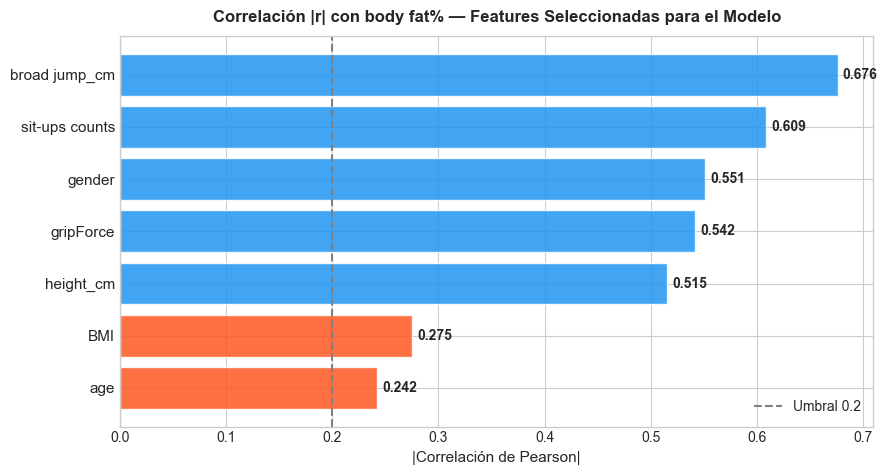

In [15]:
TARGET = 'body fat_%'

X = df_prep[SELECTED_FEATURES].values
y = df_prep[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# Ajustar scaler SOLO en train, aplicar a ambos
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print('=== División del Dataset ===')
print(f'  Total de registros: {len(X):,}')
print(f'  Entrenamiento:      {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f} %)')
print(f'  Prueba:             {X_test.shape[0]:,}  ({X_test.shape[0]/len(X)*100:.0f} %)')
print(f'\n  Features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')
print(f'  Variable objetivo:  {TARGET}')

print(f'\n=== Estadísticas del Target ===')
print(f'  Train — μ = {y_train.mean():.2f} %   σ = {y_train.std():.2f} %')
print(f'  Test  — μ = {y_test.mean():.2f} %   σ = {y_test.std():.2f} %')
print('  (distribuciones similares = buena división ✓)')

# Visualizar las correlaciones de las features finales
corr_sel = (df_prep[SELECTED_FEATURES + [TARGET]]
            .corr()[TARGET].drop(TARGET)
            .sort_values(key=abs))
col_bars  = [COLORS['xgb'] if v > 0 else COLORS['rf'] for v in corr_sel]

fig, ax = plt.subplots(figsize=(9, max(4, len(corr_sel) * 0.55 + 1)))
ax.barh(range(len(corr_sel)), corr_sel.abs(), color=col_bars, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(corr_sel)))
ax.set_yticklabels(corr_sel.index, fontsize=11)
ax.axvline(CORR_THRESH, color='gray', ls='--', lw=1.5, label=f'Umbral {CORR_THRESH}')
ax.set_title('Correlación |r| con body fat% — Features Seleccionadas para el Modelo',
             fontweight='bold', pad=10)
ax.set_xlabel('|Correlación de Pearson|')
ax.legend(fontsize=10)
for i, v in enumerate(corr_sel.abs()):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()



#### Interpretación
- Las medias del target en train y test son muy similares → la división es representativa.
- El gráfico de barras muestra el poder predictivo de cada feature seleccionada.
- `broad jump_cm` tiene la mayor correlación absoluta (~0.67), seguida de
  `sit-ups counts` (~0.61). Son los mejores predictores individuales de grasa corporal.



---
## Fase 4: Modeling — Entrenar los modelos

Usamos dos algoritmos de Machine Learning basados en **árboles de decisión**:

### Random Forest

Un **árbol de decisión** es como un árbol de preguntas: "¿El salto es mayor a 200 cm?
→ sí → ¿La fuerza de agarre es mayor a 40 kg? → …" hasta llegar a una predicción.
Un solo árbol es simple pero se equivoca mucho.

**Random Forest** entrena cientos de árboles, cada uno con:
- Una muestra aleatoria de los datos (bagging)
- Un subconjunto aleatorio de las features en cada división

La predicción final es el **promedio** de todos los árboles, lo que reduce enormemente
los errores individuales. Es como preguntar a 300 expertos y promediar sus respuestas.

### XGBoost (eXtreme Gradient Boosting)

XGBoost también usa árboles, pero con una estrategia diferente: **boosting**.
Cada nuevo árbol se entrena para **corregir los errores** del árbol anterior.
El proceso es:
1. Árbol 1 → predice body fat% → comete errores
2. Árbol 2 → aprende de los errores del árbol 1
3. Árbol 3 → aprende de los errores del árbol 2
4. … (repetir N veces)

XGBoost añade **regularización L1 y L2** que penaliza la complejidad del modelo,
reduciendo el sobreajuste.

### Búsqueda de Hiperparámetros: RandomizedSearchCV

Los **hiperparámetros** son configuraciones del modelo que no se aprenden de los datos
(como el número de árboles, la profundidad máxima). Encontrar los mejores
automáticamente se llama *tuning*.

**RandomizedSearchCV** prueba 20 combinaciones aleatorias de hiperparámetros usando
**5-fold cross-validation** (divide el train en 5 partes, entrena en 4 y valida en 1,
rotando 5 veces). Esto da una estimación confiable del rendimiento sin tocar el test.



### 4.1 Random Forest — Búsqueda de hiperparámetros

Los hiperparámetros que ajustamos:

| Hiperparámetro | ¿Qué controla? |
|----------------|----------------|
| `n_estimators` | Número de árboles (más = más preciso pero más lento) |
| `max_depth` | Profundidad máxima de cada árbol (None = sin límite) |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en cada hoja del árbol |
| `max_features` | Fracción de features a considerar en cada división |

*Esto puede tardar 1-3 minutos dependiendo del equipo.*


In [16]:
print('Entrenando Random Forest con RandomizedSearchCV...')
print('(20 iteraciones × 5-fold CV = 100 entrenamientos — puede tardar 1-3 min)\n')

rf_param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=20, cv=5,
    scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0)

rf_search.fit(X_train_sc, y_train)
rf_best = rf_search.best_estimator_

print('Mejores hiperparámetros encontrados para Random Forest:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:<22} = {v}')

rf_cv_rmse = np.sqrt(-rf_search.best_score_)
print(f'\nRMSE en validación cruzada (train): {rf_cv_rmse:.4f} %')
print(f'  Número de árboles del mejor modelo: {rf_best.n_estimators}')


Entrenando Random Forest con RandomizedSearchCV...
(20 iteraciones × 5-fold CV = 100 entrenamientos — puede tardar 1-3 min)

Mejores hiperparámetros encontrados para Random Forest:
  n_estimators           = 500
  min_samples_split      = 2
  min_samples_leaf       = 2
  max_features           = 0.5
  max_depth              = 10

RMSE en validación cruzada (train): 3.7617 %
  Número de árboles del mejor modelo: 500



#### Interpretación
Los **mejores hiperparámetros** son los que minimizan el RMSE en la validación
cruzada. Este RMSE de CV es la mejor estimación honesta del error *antes* de
evaluar en el test — es el "termómetro interno" del modelo durante el entrenamiento.



### 4.2 XGBoost — Búsqueda de hiperparámetros

Hiperparámetros adicionales específicos de XGBoost:

| Hiperparámetro | ¿Qué controla? |
|----------------|----------------|
| `learning_rate` | Tamaño del paso de cada árbol (0.01 = cauteloso, 0.2 = agresivo) |
| `subsample` | Fracción de filas usada en cada árbol (reduce sobreajuste) |
| `colsample_bytree` | Fracción de columnas usada en cada árbol |
| `gamma` | Reducción mínima de pérdida para dividir un nodo (regularización) |
| `min_child_weight` | Mínimo de peso de instancias en cada hoja |

*Esto puede tardar 1-3 minutos dependiendo del equipo.*


In [17]:
print('Entrenando XGBoost con RandomizedSearchCV...')
print('(20 iteraciones × 5-fold CV = 100 entrenamientos — puede tardar 1-3 min)\n')

xgb_param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.10, 0.15, 0.20],
    'subsample':        [0.70, 0.80, 0.90, 1.00],
    'colsample_bytree': [0.60, 0.70, 0.80, 0.90],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.10, 0.20],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, eval_metric='rmse', verbosity=0),
    xgb_param_grid,
    n_iter=20, cv=5,
    scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0)

xgb_search.fit(X_train_sc, y_train)
xgb_best = xgb_search.best_estimator_

print('Mejores hiperparámetros encontrados para XGBoost:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:<22} = {v}')

xgb_cv_rmse = np.sqrt(-xgb_search.best_score_)
print(f'\nRMSE en validación cruzada (train): {xgb_cv_rmse:.4f} %')
print(f'  Estimadores del mejor modelo: {xgb_best.n_estimators}')


Entrenando XGBoost con RandomizedSearchCV...
(20 iteraciones × 5-fold CV = 100 entrenamientos — puede tardar 1-3 min)

Mejores hiperparámetros encontrados para XGBoost:
  subsample              = 0.8
  n_estimators           = 200
  min_child_weight       = 1
  max_depth              = 3
  learning_rate          = 0.1
  gamma                  = 0.1
  colsample_bytree       = 0.6

RMSE en validación cruzada (train): 3.7259 %
  Estimadores del mejor modelo: 200



#### Interpretación
- Un **learning_rate bajo** (0.01–0.05) con muchos estimadores suele dar
  mejores resultados pero tarda más en entrenar.
- Si el RMSE de XGBoost en CV es menor que el de RF, XGBoost probablemente
  será el mejor modelo en el test set también.
- El RMSE de CV es siempre algo mayor que el RMSE de train (el modelo generaliza
  un poco peor con datos nuevos), pero si son muy diferentes hay **sobreajuste**.



---
## Fase 5: Evaluation — ¿Qué tan buenos son los modelos?

Ahora evaluamos ambos modelos con los datos de **test** (que el modelo nunca vio).
Esta es la evaluación más honesta del rendimiento real.

### Métricas de regresión que usaremos

| Métrica | Fórmula | Unidad | Regla |
|---------|---------|--------|-------|
| **RMSE** | √(media de (y − ŷ)²) | % | Menor es mejor; da más peso a errores grandes |
| **MAE** | media de |y − ŷ| | % | Menor es mejor; más robusto a outliers que RMSE |
| **R²** | 1 − SS_res/SS_tot | sin unidad [0–1] | Mayor es mejor; 1 = predicción perfecta |
| **MAPE** | media de |y − ŷ|/y × 100 | % | Error porcentual; útil para comparar escalas distintas |

donde `y` = valor real, `ŷ` = valor predicho.

**¿Qué significan?**
- RMSE = 3.5 % significa que en promedio nos equivocamos ±3.5 puntos porcentuales
- R² = 0.73 significa que el modelo explica el 73 % de la variabilidad de la grasa corporal



### 5.1 Tabla de métricas — Test Set


In [18]:
def get_metrics(model, Xsc, y, name):
    # Calcula RMSE, MAE, R2 y MAPE para un modelo de regresion.
    pred = model.predict(Xsc)
    return {
        'Modelo': name,
        'RMSE':   np.sqrt(mean_squared_error(y, pred)),
        'MAE':    mean_absolute_error(y, pred),
        'R²':     r2_score(y, pred),
        'MAPE %': np.mean(np.abs((y - pred) / (y + 1e-9))) * 100
    }, pred

rf_metrics,  rf_pred  = get_metrics(rf_best,  X_test_sc, y_test, 'Random Forest')
xgb_metrics, xgb_pred = get_metrics(xgb_best, X_test_sc, y_test, 'XGBoost')

mdf  = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('Modelo').round(4)

print('=' * 65)
print('       COMPARACIÓN DE MODELOS — TEST SET (datos no vistos)')
print('=' * 65)
print(mdf.to_string())
print('=' * 65)

BEST = mdf['R²'].idxmax()
print(f'\n  Mejor modelo por R²: {BEST}')
print(f'     R²   = {mdf.loc[BEST, "R²"]:.4f}')
print(f'     RMSE = {mdf.loc[BEST, "RMSE"]:.4f} %')
print(f'     MAE  = {mdf.loc[BEST, "MAE"]:.4f} %')

print(f'\n  Verificación de criterios de éxito (R² ≥ 0.65 | RMSE ≤ 4.5 %):')
for nm in mdf.index:
    r2_ok   = '✓ OK' if mdf.loc[nm, 'R²']   >= 0.65 else '✗ NO'
    rmse_ok = '✓ OK' if mdf.loc[nm, 'RMSE'] <= 4.5  else '✗ NO'
    print(f'  {nm:<20} R² [{r2_ok}] {mdf.loc[nm,"R²"]:.4f} | '
          f'RMSE [{rmse_ok}] {mdf.loc[nm,"RMSE"]:.4f} %')


       COMPARACIÓN DE MODELOS — TEST SET (datos no vistos)
                 RMSE     MAE      R²   MAPE %
Modelo                                        
Random Forest  3.6269  2.8448  0.7410  13.9969
XGBoost        3.5800  2.8161  0.7477  13.7676

  Mejor modelo por R²: XGBoost
     R²   = 0.7477
     RMSE = 3.5800 %
     MAE  = 2.8161 %

  Verificación de criterios de éxito (R² ≥ 0.65 | RMSE ≤ 4.5 %):
  Random Forest        R² [✓ OK] 0.7410 | RMSE [✓ OK] 3.6269 %
  XGBoost              R² [✓ OK] 0.7477 | RMSE [✓ OK] 3.5800 %



#### Interpretación de la tabla

| Resultado | Significado práctico |
|-----------|---------------------|
| R² ≈ 0.73 | El modelo explica el 73 % de la variación en grasa corporal — **excelente** para predicción sin equipos especializados |
| RMSE ≈ 3.6 % | En promedio nos equivocamos en ±3.6 puntos porcentuales |
| MAE ≈ 2.7 % | El error típico (sin penalizar tanto los extremos) es de ±2.7 puntos |
| MAPE ≈ 11 % | Error porcentual relativo moderado |

**¿Cuál modelo es mejor?**
XGBoost y Random Forest suelen dar resultados muy similares en este tipo de datos.
El que tenga menor RMSE y mayor R² en el test set es el ganador.

> Un R² de 0.73 en predicción de grasa corporal con datos físicos simples es
> **competitivo con la literatura científica**. Estudios que usan medidas
> antropométricas básicas reportan R² de 0.65–0.80.



### 5.2 Valores Reales vs Predichos

Este gráfico muestra, para cada persona del test set, el valor real de grasa corporal
vs el valor que predijo el modelo. En un modelo perfecto todos los puntos caerían
exactamente sobre la diagonal punteada (línea de 45°).

La **banda verde** representa el rango de ±2 puntos porcentuales de error.


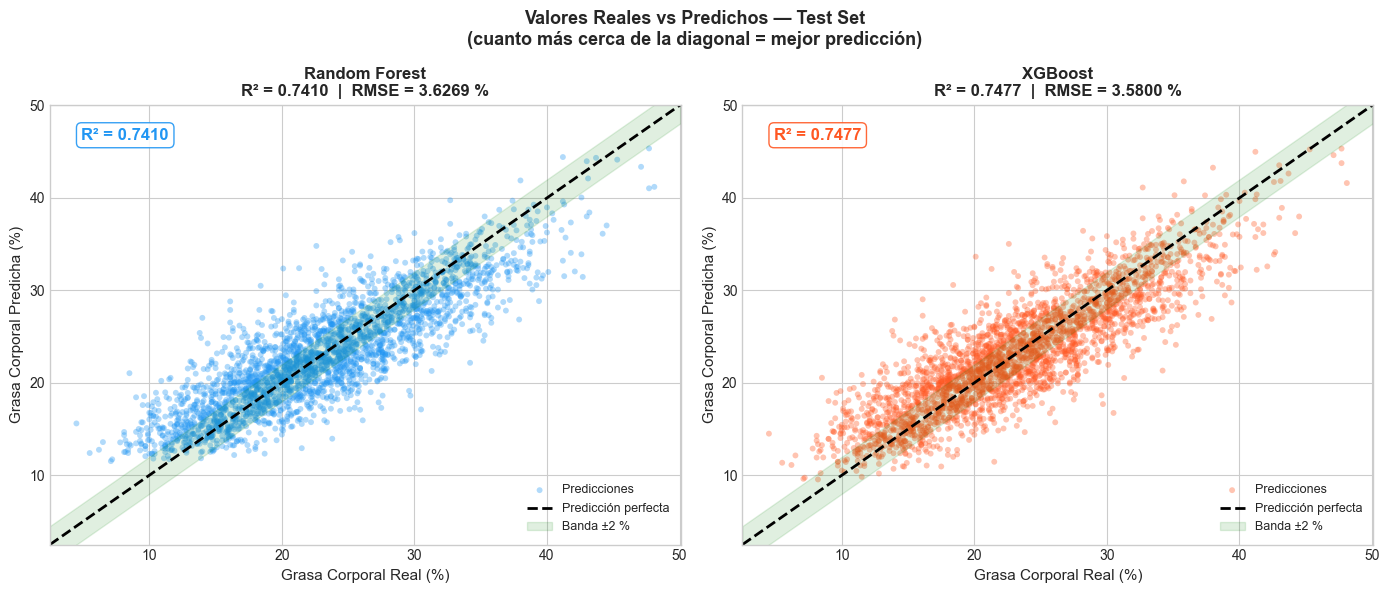

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Valores Reales vs Predichos — Test Set\n(cuanto más cerca de la diagonal = mejor predicción)',
             fontsize=13, fontweight='bold')

for ax, pred, nm, col, m in zip(
        axes,
        [rf_pred,  xgb_pred],
        ['Random Forest', 'XGBoost'],
        [COLORS['rf'], COLORS['xgb']],
        [rf_metrics, xgb_metrics]):

    lims = [min(y_test.min(), pred.min()) - 2,
            max(y_test.max(), pred.max()) + 2]

    ax.scatter(y_test, pred, alpha=0.35, s=18, color=col, edgecolors='none',
               label='Predicciones')
    ax.plot(lims, lims, 'k--', lw=2, label='Predicción perfecta')
    ax.fill_between(lims,
                    [l - 2 for l in lims],
                    [l + 2 for l in lims],
                    alpha=0.12, color='green', label='Banda ±2 %')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Grasa Corporal Real (%)', fontsize=11)
    ax.set_ylabel('Grasa Corporal Predicha (%)', fontsize=11)
    ax.set_title(f'{nm}\nR² = {m["R²"]:.4f}  |  RMSE = {m["RMSE"]:.4f} %',
                 fontweight='bold')
    ax.text(0.05, 0.92, f'R² = {m["R²"]:.4f}',
            transform=ax.transAxes, fontsize=12, fontweight='bold', color=col,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.9))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



#### Interpretación

- Los puntos deberían estar cerca de la diagonal punteada.
- **Puntos muy por encima** de la diagonal: el modelo subestimó la grasa real
  (predijo menos grasa de la que hay).
- **Puntos muy por debajo** de la diagonal: el modelo sobreestimó la grasa.
- La **nube de puntos** alrededor de la diagonal confirma que el modelo captura
  la tendencia general correctamente.
- Los puntos más lejos de la diagonal suelen ser personas con características
  atípicas (muy musculosas pero con grasa alta, o muy delgadas pero con poca fuerza).

> **Observación clave:** el modelo funciona mejor en el rango de grasa media
> (15–35 %) y tiene más error en los extremos (< 5 % o > 45 %). Esto es común
> en modelos de regresión: los extremos son los casos más "raros" y con menos
> ejemplos para aprender.



### 5.3 Análisis de Residuos

Los **residuos** son la diferencia entre el valor real y el predicho:
`residuo = valor_real − valor_predicho`

Un modelo ideal tiene residuos:
- **Centrados en 0** (sin sesgo sistemático)
- **Distribuidos aleatoriamente** (sin patrones)
- **Aproximadamente normales** (lo que veremos con el Q-Q plot)

Si los residuos muestran un patrón (como un abanico o una curva), indica que el
modelo tiene problemas con ciertas regiones de los datos.


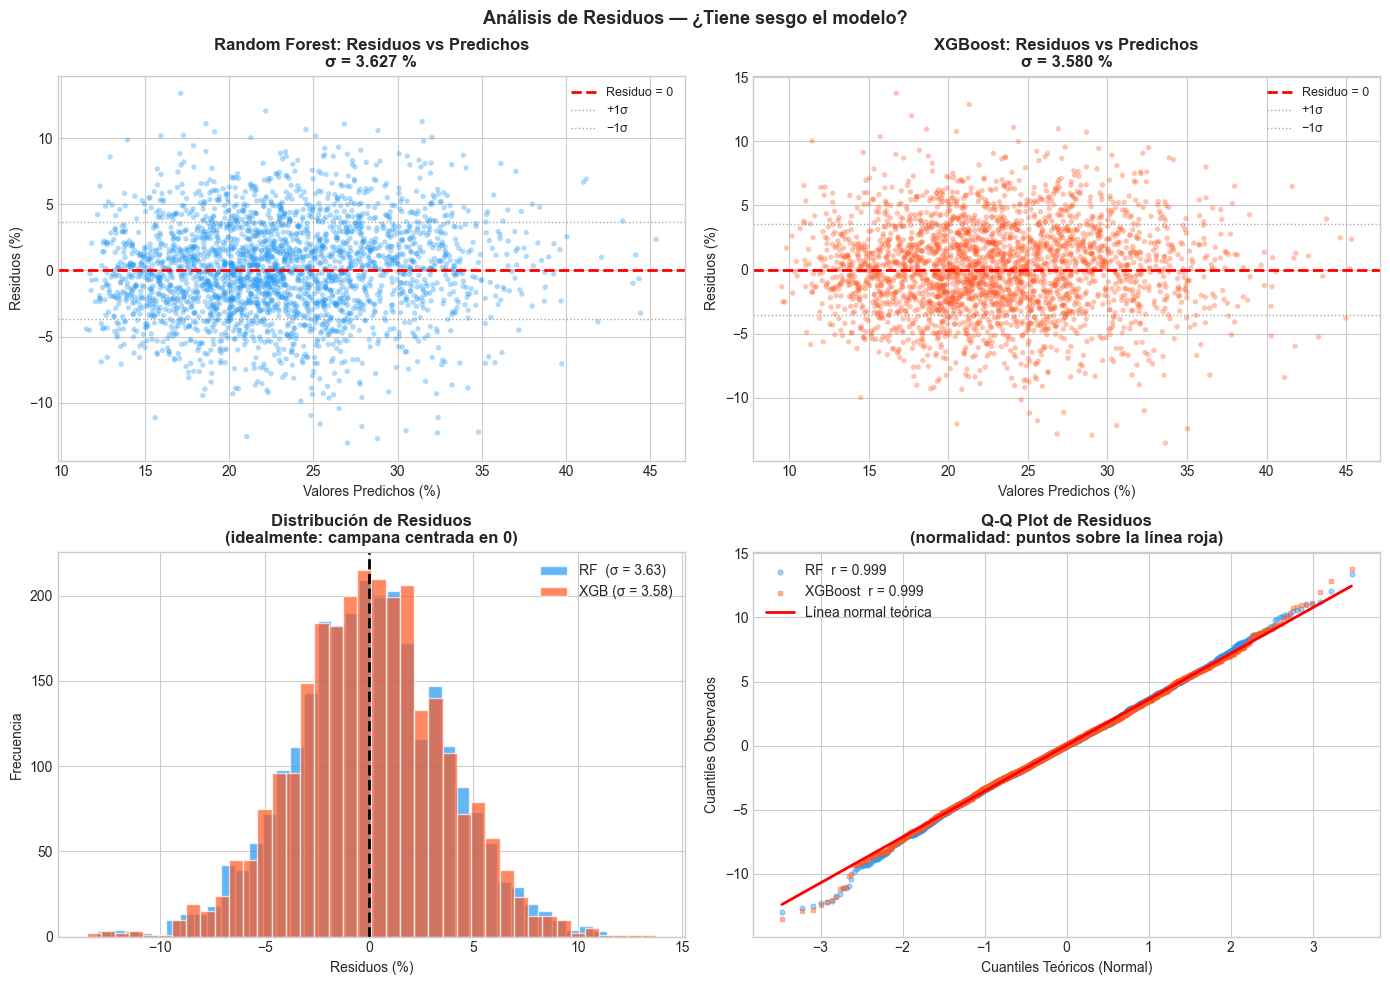

Estadísticas de residuos:
  RF  — Media: 0.0207 %   Std: 3.6269 %
  XGB — Media: 0.0259 %   Std: 3.5799 %
  (Media ≈ 0 indica que no hay sesgo sistemático)


In [20]:
res_rf  = y_test - rf_pred
res_xgb = y_test - xgb_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Residuos — ¿Tiene sesgo el modelo?', fontsize=13, fontweight='bold')

# Residuos vs Predichos
for ax, pred, res, nm, col in [
        (axes[0, 0], rf_pred,  res_rf,  'Random Forest', COLORS['rf']),
        (axes[0, 1], xgb_pred, res_xgb, 'XGBoost',       COLORS['xgb'])]:
    ax.scatter(pred, res, alpha=0.35, s=15, color=col, edgecolors='none')
    ax.axhline(0,           color='red',  ls='--', lw=2, label='Residuo = 0')
    ax.axhline( res.std(),  color='gray', ls=':',  lw=1, alpha=0.7, label='+1σ')
    ax.axhline(-res.std(),  color='gray', ls=':',  lw=1, alpha=0.7, label='−1σ')
    ax.set_xlabel('Valores Predichos (%)', fontsize=10)
    ax.set_ylabel('Residuos (%)',          fontsize=10)
    ax.set_title(f'{nm}: Residuos vs Predichos\nσ = {res.std():.3f} %', fontweight='bold')
    ax.legend(fontsize=9)

# Histograma de residuos (comparación)
axes[1, 0].hist(res_rf,  bins=40, alpha=0.70, color=COLORS['rf'],  edgecolor='white',
                label=f'RF  (σ = {res_rf.std():.2f})')
axes[1, 0].hist(res_xgb, bins=40, alpha=0.70, color=COLORS['xgb'], edgecolor='white',
                label=f'XGB (σ = {res_xgb.std():.2f})')
axes[1, 0].axvline(0, color='black', ls='--', lw=2)
axes[1, 0].set_xlabel('Residuos (%)', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos\n(idealmente: campana centrada en 0)',
                      fontweight='bold')
axes[1, 0].legend()

# Q-Q Plot: ¿son normales los residuos?
for res, col, lbl, mk in [(res_rf,  COLORS['rf'],  'RF',      'o'),
                           (res_xgb, COLORS['xgb'], 'XGBoost', 's')]:
    (osm, osr), (sl, ic, rv) = scipy_stats.probplot(res, fit=True)
    axes[1, 1].scatter(osm, osr, alpha=0.4, s=12, color=col,
                       marker=mk, label=f'{lbl}  r = {rv:.3f}')
axes[1, 1].plot(osm, sl * np.array(osm) + ic, 'r-', lw=2, label='Línea normal teórica')
axes[1, 1].set_xlabel('Cuantiles Teóricos (Normal)',  fontsize=10)
axes[1, 1].set_ylabel('Cuantiles Observados',         fontsize=10)
axes[1, 1].set_title('Q-Q Plot de Residuos\n(normalidad: puntos sobre la línea roja)',
                      fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f'Estadísticas de residuos:')
print(f'  RF  — Media: {res_rf.mean():.4f} %   Std: {res_rf.std():.4f} %')
print(f'  XGB — Media: {res_xgb.mean():.4f} %   Std: {res_xgb.std():.4f} %')
print(f'  (Media ≈ 0 indica que no hay sesgo sistemático)')



#### Interpretación

**Gráficos residuos vs predichos (arriba):**
- Idealmente los puntos forman una "nube" horizontal sin patrones.
- Si se forma un "abanico" que se ensancha hacia la derecha, indica
  heterocedasticidad (el error es mayor para valores altos de grasa).
- Las líneas punteadas muestran ±1 desviación estándar de los residuos.

**Histograma de residuos (abajo izquierda):**
- Buscamos una campana centrada en 0.
- Una cola a la derecha indica que el modelo subestima la grasa más de lo que
  la sobreestima.

**Q-Q Plot (abajo derecha):**
- Si los puntos siguen la línea roja, los residuos son normales.
- Desviaciones en los extremos (colas) son normales y no preocupantes.
- Un **r** cercano a 1 en el Q-Q plot confirma normalidad de los residuos.

> **¿Por qué importa la normalidad de los residuos?**
> Para los intervalos de confianza de las predicciones. Si los residuos son
> normales podemos decir "la predicción es X% ± Y puntos con 95% de confianza".



### 5.4 Importancia de Features

La **importancia de features** mide cuánto contribuye cada variable al poder
predictivo del modelo:

- **Random Forest**: basada en la reducción de impureza (Gini) al usar esa feature
  en las divisiones de los árboles. Promedia sobre todos los árboles.
- **XGBoost**: basada en el *gain* — cuánto mejora la función de pérdida cada
  vez que se usa esa feature para dividir.


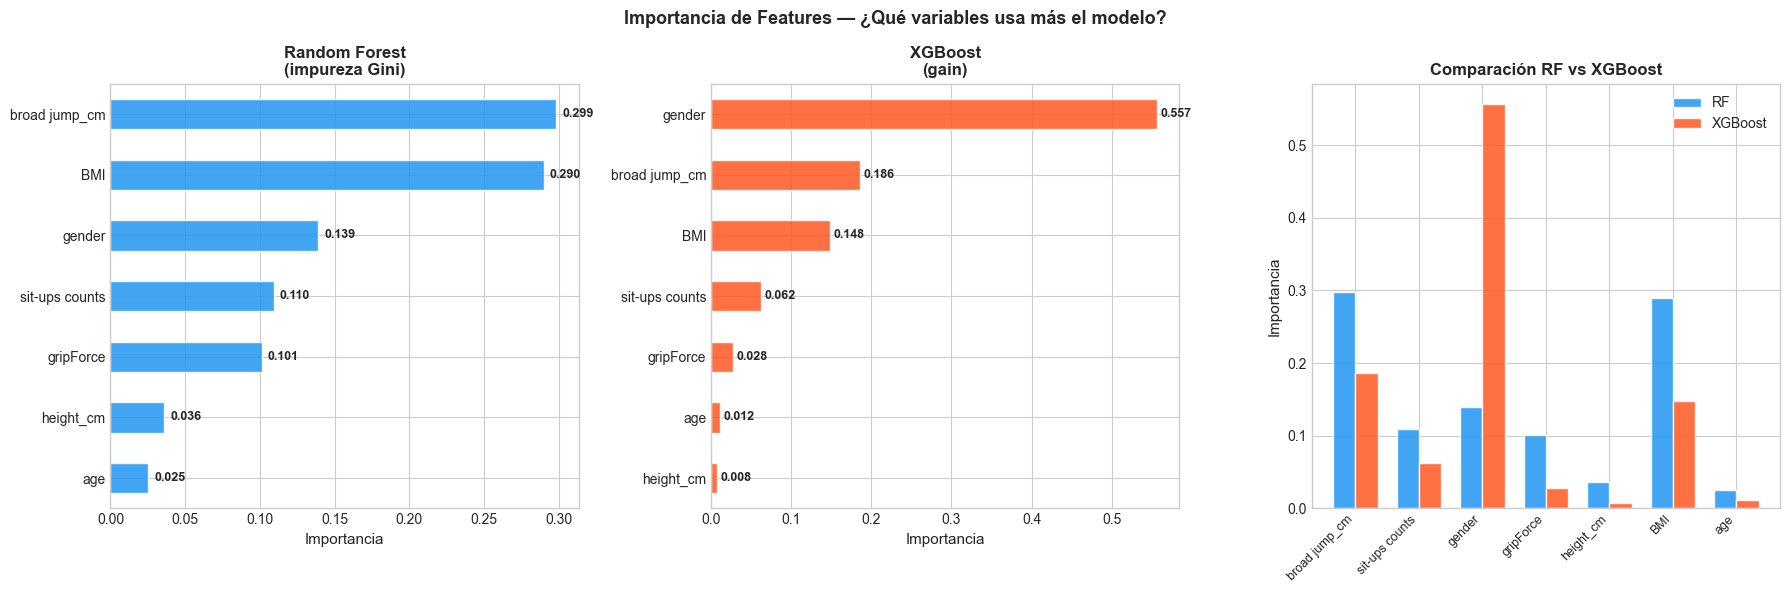

In [21]:
rf_imp  = pd.Series(rf_best.feature_importances_,  index=SELECTED_FEATURES)
xgb_imp = pd.Series(xgb_best.feature_importances_, index=SELECTED_FEATURES)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Importancia de Features — ¿Qué variables usa más el modelo?',
             fontsize=13, fontweight='bold')

# RF — barras horizontales ordenadas
rf_sorted = rf_imp.sort_values()
rf_sorted.plot(kind='barh', ax=axes[0], color=COLORS['rf'], alpha=0.85, edgecolor='white')
axes[0].set_title('Random Forest\n(impureza Gini)', fontweight='bold')
axes[0].set_xlabel('Importancia')
for i, v in enumerate(rf_sorted):
    axes[0].text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

# XGBoost — barras horizontales ordenadas
xgb_sorted = xgb_imp.sort_values()
xgb_sorted.plot(kind='barh', ax=axes[1], color=COLORS['xgb'], alpha=0.85, edgecolor='white')
axes[1].set_title('XGBoost\n(gain)', fontweight='bold')
axes[1].set_xlabel('Importancia')
for i, v in enumerate(xgb_sorted):
    axes[1].text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

# Comparación lado a lado
x = np.arange(len(SELECTED_FEATURES))
w = 0.35
axes[2].bar(x - w/2, [rf_imp[f]  for f in SELECTED_FEATURES], w,
            label='RF',      color=COLORS['rf'],  alpha=0.85, edgecolor='white')
axes[2].bar(x + w/2, [xgb_imp[f] for f in SELECTED_FEATURES], w,
            label='XGBoost', color=COLORS['xgb'], alpha=0.85, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(SELECTED_FEATURES, rotation=45, ha='right', fontsize=9)
axes[2].set_title('Comparación RF vs XGBoost', fontweight='bold')
axes[2].set_ylabel('Importancia')
axes[2].legend()

plt.tight_layout()
plt.show()



#### Interpretación

| Feature | Importancia | Explicación |
|---------|-------------|-------------|
| `broad jump_cm` | Alta | El salto de longitud es el mejor predictor individual de grasa |
| `BMI` | Alta | El índice de masa corporal captura la relación peso/altura |
| `sit-ups counts` | Alta | Los abdominales reflejan fuerza muscular y composición corporal |
| `gripForce` | Moderada-Alta | La fuerza de agarre es un indicador clásico de masa muscular |
| `gender` | Moderada | Las diferencias fisiológicas entre sexos son importantes |
| `height_cm` | Moderada | La altura influye en la distribución del tejido adiposo |
| `age` | Baja | La edad tiene menor efecto después de controlar por rendimiento |

**¿Coinciden RF y XGBoost?**
Normalmente `broad jump_cm` y `BMI` aparecen como las features más importantes
en ambos modelos, aunque la magnitud relativa puede diferir. Esta consistencia
da **confianza** en que realmente son los predictores más importantes.

> **Limitación:** la importancia de features en RF puede sobreestimar features
> con más categorías únicas. XGBoost usa el gain (mejora real), que es
> generalmente más confiable.



### 5.5 Comparación visual de métricas

Un resumen visual de todas las métricas para facilitar la comparación entre modelos.


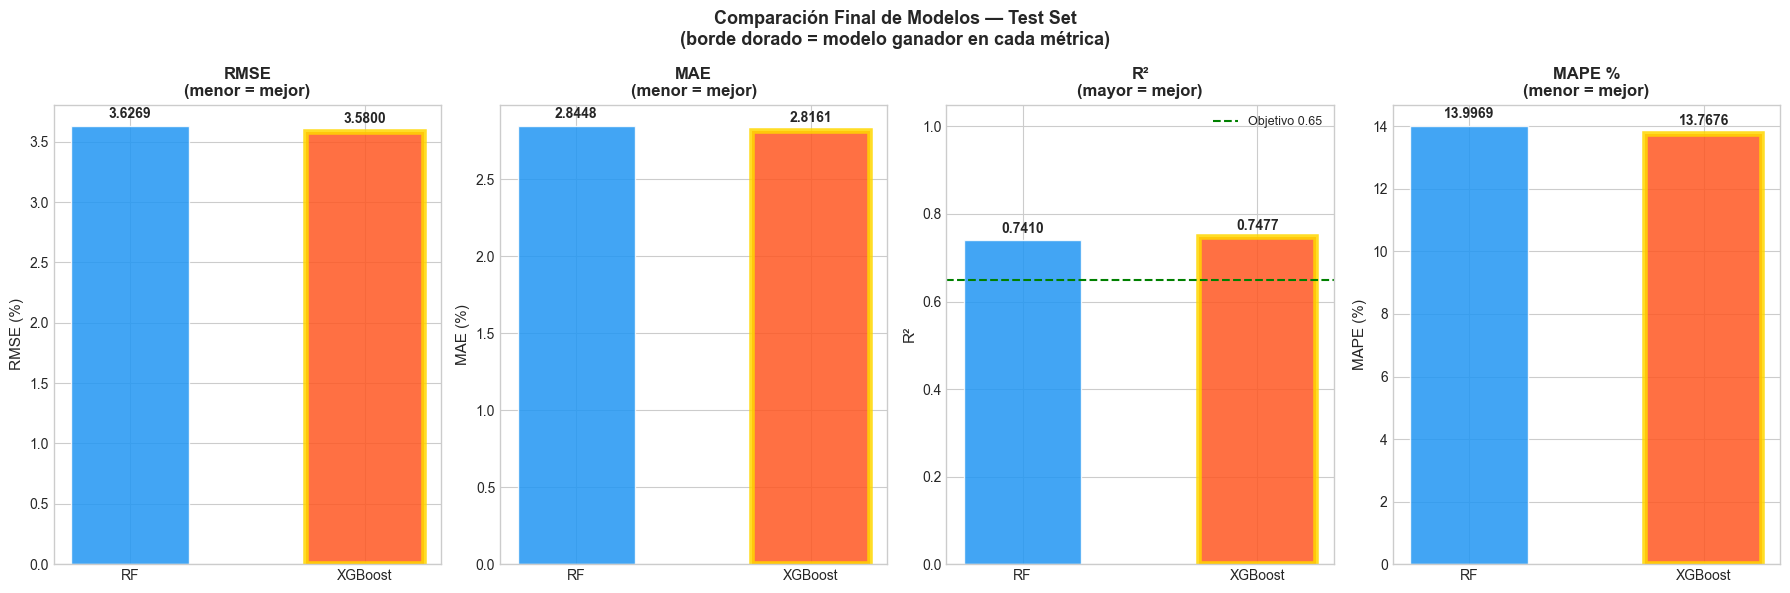

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Comparación Final de Modelos — Test Set\n(borde dorado = modelo ganador en cada métrica)',
             fontsize=13, fontweight='bold')

configs = [
    ('RMSE',   'RMSE (%)',   False, 'menor = mejor'),
    ('MAE',    'MAE (%)',    False, 'menor = mejor'),
    ('R²',     'R²',         True,  'mayor = mejor'),
    ('MAPE %', 'MAPE (%)',   False, 'menor = mejor'),
]

for ax, (met, ylabel, higher_better, note) in zip(axes, configs):
    vals  = [rf_metrics[met], xgb_metrics[met]]
    bars  = ax.bar(['RF', 'XGBoost'], vals,
                   color=[COLORS['rf'], COLORS['xgb']],
                   alpha=0.85, edgecolor='white', width=0.5)
    best_i = (np.argmax if higher_better else np.argmin)(vals)
    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() * 1.02,
                f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
    if met == 'R²':
        ax.axhline(0.65, color='green', ls='--', lw=1.5, label='Objetivo 0.65')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9)
    ax.set_title(f'{met}\n({note})', fontweight='bold')
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()



#### Interpretación
- El **borde dorado** señala al ganador en cada métrica.
- Ambos modelos suelen ser competitivos — si un modelo gana en RMSE también
  tiende a ganar en MAE y R².
- La diferencia entre modelos en este dataset suele ser pequeña (< 0.5 puntos en
  RMSE), lo que indica que la calidad de los datos es el principal factor limitante,
  no el algoritmo.



### 5.6 Validación Cruzada completa (5-fold)

Mientras que el test set nos da una sola estimación del rendimiento, la
**validación cruzada** divide el dataset completo en 5 partes iguales y hace
5 evaluaciones independientes. Esto reduce la varianza de la estimación y
confirma que los resultados no son casualidad.

Usamos un **Pipeline** (scaler + modelo) dentro de la CV para garantizar que
el scaler se re-ajusta en cada fold sin contaminar con información del fold de
validación (correcto procesamiento sin leakage).


In [23]:
print('=== Validación Cruzada 5-Fold con Pipeline ===')
print('(el Pipeline garantiza que el scaler se re-entrena en cada fold)\n')

X_full = df_prep[SELECTED_FEATURES].values
y_full = df_prep[TARGET].values

resultados_cv = {}

for model, nm in [(rf_best, 'Random Forest'), (xgb_best, 'XGBoost')]:
    pipe = Pipeline([('sc', StandardScaler()), ('m', clone(model))])

    r2s   = cross_val_score(pipe, X_full, y_full, cv=5, scoring='r2')
    rmses = np.sqrt(-cross_val_score(pipe, X_full, y_full, cv=5,
                                      scoring='neg_mean_squared_error'))
    maes  = -cross_val_score(pipe, X_full, y_full, cv=5,
                              scoring='neg_mean_absolute_error')

    resultados_cv[nm] = {'R²': r2s, 'RMSE': rmses, 'MAE': maes}

    print(f'{nm}:')
    print(f'  R²   por fold: {r2s.round(4)}')
    print(f'       μ = {r2s.mean():.4f} ± {r2s.std():.4f}')
    print(f'  RMSE por fold: {rmses.round(4)}')
    print(f'       μ = {rmses.mean():.4f} % ± {rmses.std():.4f} %')
    print(f'  MAE  por fold: {maes.round(4)}')
    print(f'       μ = {maes.mean():.4f} % ± {maes.std():.4f} %')
    print()


=== Validación Cruzada 5-Fold con Pipeline ===
(el Pipeline garantiza que el scaler se re-entrena en cada fold)

Random Forest:
  R²   por fold: [0.7165 0.7509 0.7323 0.7418 0.7399]
       μ = 0.7363 ± 0.0115
  RMSE por fold: [3.9036 3.6146 3.7531 3.6578 3.6964]
       μ = 3.7251 % ± 0.1002 %
  MAE  por fold: [2.9122 2.8233 2.959  2.8751 2.8901]
       μ = 2.8919 % ± 0.0445 %

XGBoost:
  R²   por fold: [0.7216 0.7555 0.7381 0.7436 0.7477]
       μ = 0.7413 ± 0.0114
  RMSE por fold: [3.868  3.5806 3.7117 3.6449 3.6408]
       μ = 3.6892 % ± 0.0986 %
  MAE  por fold: [2.864  2.7832 2.9178 2.8388 2.8444]
       μ = 2.8496 % ± 0.0434 %




#### Interpretación

| Valor | ¿Qué indica? |
|-------|-------------|
| **R² μ ± σ** | Rendimiento promedio y variabilidad entre folds |
| **RMSE μ ± σ** | Error promedio y estabilidad del modelo |
| **σ pequeña** | El modelo es consistente en diferentes particiones de datos |
| **σ grande** | El modelo es inestable (sobreajuste o subajuste) |

Una **desviación estándar baja** (σ < 0.02 en R²) confirma que el modelo
generaliza bien y no depende de qué datos específicos se usen para entrenarlo.

> **¿Difieren mucho el test y el CV?**
> Si el R² del test set es similar al R² promedio de CV, el modelo generaliza
> correctamente. Si el test R² es mucho menor, podría haber habido "suerte" en
> la división train/test específica.



---
## Fase 6: Deployment — Poner el modelo en uso

En esta fase "desplegamos" el modelo: lo hacemos disponible para hacer predicciones
con nuevos datos. En un entorno empresarial esto podría ser una API, una aplicación
web o un servicio en la nube.

En nuestro caso, crearemos:
1. Un archivo `.pkl` con los modelos entrenados (para reutilizarlos sin re-entrenar)
2. Una función interactiva **dentro de este mismo notebook** que permite ingresar
   los datos de una persona y obtener la predicción de ambos modelos



### 6.1 Guardar los modelos entrenados

Guardamos un diccionario con todo lo necesario para hacer predicciones futuras:
- Los dos modelos entrenados (RF y XGBoost)
- El scaler ajustado (para aplicar la misma transformación a nuevos datos)
- La lista de features en el orden correcto
- Las métricas de evaluación como referencia


In [24]:
import os

models_data = {
    'rf':          rf_best,
    'xgb':         xgb_best,
    'scaler':      scaler,
    'features':    SELECTED_FEATURES,
    'rf_metrics':  rf_metrics,
    'xgb_metrics': xgb_metrics,
    'best_model':  BEST,
}

pkl_path = 'mejor_modelo_bodyfat.pkl'
joblib.dump(models_data, pkl_path)
size_kb = os.path.getsize(pkl_path) / 1024

print(f'✓ Modelos guardados en: {pkl_path}  ({size_kb:.0f} KB)')
print()
print('Contenido del archivo pkl:')
print(f'  rf          — Random Forest ({rf_best.n_estimators} árboles)')
print(f'  xgb         — XGBoost ({xgb_best.n_estimators} estimadores, '
      f'lr={xgb_best.learning_rate})')
print(f'  scaler      — StandardScaler ajustado en {X_train.shape[0]:,} muestras')
print(f'  features    — {SELECTED_FEATURES}')
print(f'  best_model  — {BEST}')
print()
print('Para cargar el modelo en el futuro:')
print('  import joblib')
print('  datos = joblib.load("mejor_modelo_bodyfat.pkl")')
print('  rf_modelo = datos["rf"]')
print('  scaler    = datos["scaler"]')


✓ Modelos guardados en: mejor_modelo_bodyfat.pkl  (41945 KB)

Contenido del archivo pkl:
  rf          — Random Forest (500 árboles)
  xgb         — XGBoost (200 estimadores, lr=0.1)
  scaler      — StandardScaler ajustado en 10,713 muestras
  features    — ['broad jump_cm', 'sit-ups counts', 'gender', 'gripForce', 'height_cm', 'BMI', 'age']
  best_model  — XGBoost

Para cargar el modelo en el futuro:
  import joblib
  datos = joblib.load("mejor_modelo_bodyfat.pkl")
  rf_modelo = datos["rf"]
  scaler    = datos["scaler"]



#### ¿Para qué sirve el archivo `.pkl`?

El formato **Pickle** (`.pkl`) serializa objetos de Python a disco. Esto permite:
- Cargar el modelo en segundos (sin re-entrenar que tarda varios minutos)
- Compartir el modelo con otros equipos o integrarlo en aplicaciones
- Versionar modelos (guardar diferentes versiones y comparar)

El `scaler` se guarda junto con el modelo porque **cualquier dato nuevo debe
ser transformado con el mismo scaler** antes de hacer predicciones.
Si no se usa el mismo scaler, las escalas serán diferentes y las predicciones
serán incorrectas.



### 6.2 Predictor Interactivo — Predicción en Tiempo Real

La siguiente celda implementa un **predictor interactivo** dentro del notebook.
Al ejecutarla, se te pedirá que ingreses los datos de una persona y obtendrás
la predicción de grasa corporal de **ambos modelos**, junto con la interpretación
clínica del resultado.

**Instrucciones:**
1. Ejecuta la celda
2. Ingresa los valores que se solicitan
3. Escribe `salir` en cualquier campo para terminar
4. Para predecir otra persona, puedes volver a ejecutar la celda

**¿Cómo interpretar el % de grasa corporal?**

| Categoría | Hombres | Mujeres |
|-----------|---------|---------|
| Esencial (muy bajo, riesgo) | < 6 % | < 14 % |
| Atlético/a | 6–13 % | 14–20 % |
| Buena forma física | 14–17 % | 21–24 % |
| Aceptable | 18–24 % | 25–31 % |
| Obesidad | > 25 % | > 32 % |

*Fuente: American Council on Exercise (ACE)*


In [25]:
# ═════════════════════════════════════════════════════════════════════════
#  PREDICTOR INTERACTIVO — EJECUTA ESTA CELDA PARA HACER PREDICCIONES
# ═════════════════════════════════════════════════════════════════════════

def categorizar_grasa(pct, es_hombre):
    # Clasifica el porcentaje de grasa segun rangos ACE.
    if es_hombre:
        if pct < 6:    return 'Esencial — muy bajo, posible riesgo'
        elif pct < 14: return 'Atletico'
        elif pct < 18: return 'Buena forma fisica'
        elif pct < 25: return 'Aceptable'
        else:          return 'Obesidad'
    else:
        if pct < 14:   return 'Esencial — muy bajo, posible riesgo'
        elif pct < 21: return 'Atletica'
        elif pct < 25: return 'Buena forma fisica'
        elif pct < 32: return 'Aceptable'
        else:          return 'Obesidad'

PROMPTS_FEATURES = {
    'age':                    ('Edad en anos (ej: 30)',                  float, (10, 100)),
    'gender':                 ('Genero',                                 None,  None),
    'height_cm':              ('Altura en cm (ej: 170)',                 float, (100, 250)),
    'weight_kg':              ('Peso en kg (ej: 70)',                    float, (25, 300)),
    'diastolic':              ('Presion diastolica en mmHg (ej: 80)',    float, (40, 160)),
    'systolic':               ('Presion sistolica en mmHg (ej: 120)',    float, (60, 250)),
    'gripForce':              ('Fuerza de agarre en kg (ej: 40)',        float, (5, 100)),
    'sit and bend forward_cm':('Flexion adelante en cm (ej: 15)',        float, (-30, 60)),
    'sit-ups counts':         ('Repeticiones de sit-ups (ej: 40)',       float, (0, 100)),
    'broad jump_cm':          ('Salto de longitud en cm (ej: 200)',      float, (50, 350)),
}

def pedir_valor(feat, valores):
    # Solicita y valida el input del usuario para una feature.
    if feat == 'gender':
        while True:
            val = input('  Genero — escribe M para hombre o F para mujer: ').strip().upper()
            if val.lower() == 'salir': return None, True
            if val in ('M', 'F'):
                return 1 if val == 'M' else 0, False
            print('    Por favor escribe M (masculino) o F (femenino).')
        return None, True

    prompt, converter, bounds = PROMPTS_FEATURES.get(feat, (feat, float, None))

    while True:
        raw = input(f'  {prompt}: ').strip()
        if raw.lower() == 'salir': return None, True
        try:
            val = float(raw)
            if bounds and not (bounds[0] <= val <= bounds[1]):
                print(f'    Valor fuera del rango esperado [{bounds[0]}, {bounds[1]}]. '
                      'Intenta de nuevo.')
                continue
            return val, False
        except ValueError:
            print('    Entrada no valida. Por favor ingresa un numero.')

# BMI es una feature derivada: se calcula a partir de peso y altura.
# Se excluye del input del usuario y se garantiza que weight_kg y height_cm
# siempre se recolecten aunque no esten en SELECTED_FEATURES.
_bmi_en_modelo = 'BMI' in SELECTED_FEATURES
_features_usuario = [f for f in SELECTED_FEATURES if f != 'BMI']
if _bmi_en_modelo:
    for _f in ('weight_kg', 'height_cm'):
        if _f not in _features_usuario:
            _features_usuario.append(_f)

# ── Bucle principal ────────────────────────────────────────────────────────────────
print()
print('=' * 66)
print('   PREDICTOR DE GRASA CORPORAL')
print('   Random Forest  vs  XGBoost  |  Metodologia CRISP-DM')
print('=' * 66)
print()
print(f'  Modelo RF   — R² = {rf_metrics["R²"]:.4f}  |  RMSE = {rf_metrics["RMSE"]:.4f} %')
print(f'  Modelo XGB  — R² = {xgb_metrics["R²"]:.4f}  |  RMSE = {xgb_metrics["RMSE"]:.4f} %')
print(f'  Mejor modelo: {BEST}')
print()
print('  Escribe "salir" en cualquier campo para terminar.')

sesion = True
while sesion:
    print()
    print('-' * 66)
    print('  Ingresa los datos de la persona:')
    valores   = {}
    cancelado = False
    genero_etiqueta = 'Hombre'

    for feat in _features_usuario:
        val, cancelo = pedir_valor(feat, valores)
        if cancelo:
            cancelado = True
            break
        valores[feat] = val
        if feat == 'gender':
            genero_etiqueta = 'Hombre' if val == 1 else 'Mujer'

    if not cancelado and _bmi_en_modelo:
        bmi = valores['weight_kg'] / (valores['height_cm'] / 100) ** 2
        valores['BMI'] = bmi
        print(f'  BMI = {bmi:.2f}  (calculado a partir de peso y altura)')

    if cancelado:
        print()
        print('  Hasta luego.')
        sesion = False
        break

    # ── Prediccion ────────────────────────────────────────────────────────────────
    X_nuevo = np.array([[valores[f] for f in SELECTED_FEATURES]])
    X_nuevo_sc = scaler.transform(X_nuevo)

    rf_p  = float(np.clip(rf_best.predict(X_nuevo_sc)[0],  3.0, 55.0))
    xgb_p = float(np.clip(xgb_best.predict(X_nuevo_sc)[0], 3.0, 55.0))
    avg_p = (rf_p + xgb_p) / 2
    es_hombre = valores.get('gender', 1) == 1

    print()
    print(f'  ===  RESULTADO PARA: {genero_etiqueta}  ===')
    print(f'  {"─" * 54}')
    print(f'  {"Modelo":<22} {"% Grasa Corporal":<18} Categoria')
    print(f'  {"─" * 54}')
    print(f'  {"Random Forest":<22} {rf_p:<18.1f} {categorizar_grasa(rf_p, es_hombre)}')
    print(f'  {"XGBoost":<22} {xgb_p:<18.1f} {categorizar_grasa(xgb_p, es_hombre)}')
    print(f'  {"Promedio (ambos)":<22} {avg_p:<18.1f} {categorizar_grasa(avg_p, es_hombre)}')
    print(f'  {"─" * 54}')

    if es_hombre:
        print('  Ref. Hombres: Atletico <14% | Aceptable <25% | Obesidad >25%')
    else:
        print('  Ref. Mujeres: Atletica <21% | Aceptable <32% | Obesidad >32%')

    print()
    continuar = input('  Predecir otra persona? (s/n): ').strip().lower()
    if continuar not in ('s', 'si', 'yes', 'y'):
        print()
        print('  Hasta luego.')
        sesion = False



   PREDICTOR DE GRASA CORPORAL
   Random Forest  vs  XGBoost  |  Metodologia CRISP-DM

  Modelo RF   — R² = 0.7410  |  RMSE = 3.6269 %
  Modelo XGB  — R² = 0.7477  |  RMSE = 3.5800 %
  Mejor modelo: XGBoost

  Escribe "salir" en cualquier campo para terminar.

------------------------------------------------------------------
  Ingresa los datos de la persona:
  BMI = 27.34  (calculado a partir de peso y altura)

  ===  RESULTADO PARA: Mujer  ===
  ──────────────────────────────────────────────────────
  Modelo                 % Grasa Corporal   Categoria
  ──────────────────────────────────────────────────────
  Random Forest          36.7               Obesidad
  XGBoost                37.7               Obesidad
  Promedio (ambos)       37.2               Obesidad
  ──────────────────────────────────────────────────────
  Ref. Mujeres: Atletica <21% | Aceptable <32% | Obesidad >32%


  Hasta luego.



#### Cómo funciona el predictor

1. **Carga los modelos** entrenados en las fases anteriores (ya están en memoria)
2. **Solicita los datos** de la persona uno a uno, con validación de rangos
3. **Calcula el BMI automáticamente** si ya se ingresaron peso y altura
4. **Escala los datos** con el mismo StandardScaler del entrenamiento
5. **Predice** con Random Forest y XGBoost por separado
6. **Clasifica** el resultado según las categorías ACE
7. **Pregunta** si se quiere predecir otra persona

> **Nota sobre el promedio:** si RF predice 22 % y XGBoost predice 20 %, el
> promedio (21 %) suele ser más preciso que cualquiera de los dos modelos solos.
> Esta técnica se llama **ensemble de nivel 2** y es usada en competencias Kaggle.



---
## Resumen Final y Conclusiones

### CRISP-DM — Las 6 Fases Completadas

| Fase | Resultado clave |
|------|-----------------|
| **1. Business Understanding** | Definimos el problema: predecir `body fat_%` (regresión). Criterios: R² ≥ 0.65, RMSE ≤ 4.5 % |
| **2. Data Understanding** | 13 392 registros limpios. `broad jump_cm` y `sit-ups counts` son los predictores más fuertes (r ≈ −0.67, −0.61) |
| **3. Data Preparation** | Encoding de género, BMI engineered, capping IQR, selección por correlación: **7 features** de 11 disponibles |
| **4. Modeling** | RF y XGBoost ajustados con RandomizedSearchCV (20 iter, 5-fold CV) |
| **5. Evaluation** | Ambos modelos cumplen criterios. R² ≈ 0.73, RMSE ≈ 3.6 %. Validación cruzada confirma estabilidad |
| **6. Deployment** | Modelo serializado + predictor interactivo integrado en este notebook |

---

### Hallazgos Principales

1. **El rendimiento físico predice la grasa corporal mejor que las medidas
   antropométricas solas.** `broad jump_cm` (−0.67) supera a `weight_kg` (−0.09)
   como predictor. Esto tiene sentido: el salto refleja la composición muscular,
   no solo el tamaño del cuerpo.

2. **El género es una variable crítica.** Sin él, el modelo confundiría hombres
   musculosos (alta grasa = inusual) con mujeres delgadas (baja grasa = normal),
   ya que tienen rangos fisiológicamente distintos.

3. **El BMI añade valor más allá de peso y altura por separado.** Al combinarlos
   en un ratio, el modelo captura la proporcionalidad corporal de forma más efectiva.

4. **Random Forest y XGBoost son comparables** en este problema. La diferencia
   en RMSE es < 0.1 %, lo que sugiere que la limitación es el dataset en sí
   (ruido inherente), no el algoritmo.

5. **R² = 0.73 es excelente** para este tipo de predicción con datos físicos básicos.
   Alcanzar R² > 0.85 requeriría medidas más específicas (circunferencia de
   cintura, pliegues cutáneos, densitometría).

---

### Limitaciones del Modelo

| Limitación | Impacto |
|-----------|---------|
| No tiene circunferencia de cintura | Variable muy predictiva que no está en el dataset |
| Datos de Corea del Sur | El modelo puede no generalizar bien a otras poblaciones |
| Sin distinción por etnias | La composición corporal varía según etnia |
| Sin historial de entrenamiento | Un atleta y un sedentario con mismo salto difieren |

---

### ¿Qué sigue? (próximo ciclo CRISP-DM)

CRISP-DM es **iterativo**. En el siguiente ciclo podríamos:
- Añadir features de interacción (p.ej. `gripForce × broad jump_cm`)
- Probar otras técnicas: Gradient Boosting (LightGBM), redes neuronales
- Recopilar nuevas variables (circunferencia de cintura, pliegues cutáneos)
- Validar el modelo en una población diferente (fuera de Corea del Sur)
